In [25]:
from scipy.stats import linregress
import numpy as np
from scipy.special import binom
from collections import namedtuple

# GEM5 Analysis Dependencies
import pandas as pd
from io import StringIO
import io
from scipy.optimize import curve_fit
#from scipy.optimize import lsq_linear
#from sklearn.linear_model import LinearRegression
import math

#  Plotting depdencies
import matplotlib.pyplot as plt
#from matplotlib.ticker import LogLocator, LogFormatter
#from matplotlib.ticker import FuncFormatter
import copy

In [2]:
#  -- Machine configuration

LanesPerUpdown = 64
LanesPerNode = 32*LanesPerUpdown
RoundtripTime = 2.5e-6

DRAMBandwidthStack = 1200e9 # 1200 GB/s
DRAMBandwidth = DRAMBandwidthStack*8

NetworkInjectionPerNodeBandwidth = 4.4e12 #two 2.2TB/s links
UPDATE_BFS_TOO = False

RENDER_LOC="./"

#PR

In [ ]:
# def Graph500_isolated_nodes(scale):
#     a = .57
#     b = .19
#     p = a + b
#     isolated_nodes = 0
#     for i in range(scale+1):
#         P_i = (p**i)*(1-p)**(scale -i)
#         z = 2*np.log(1-P_i)*(16*2**scale)
#         # factor of 2 is to account for the in and out degrees both being 0.
#         isolated_nodes += np.exp(np.log(binom(scale,i)) + z)

#     return isolated_nodes

# #
# #  PageRank Data Models
# #


# def pr_er_dataset_projection(scale):
#     num_verts = 2**scale
#     num_edges = np.log(num_verts) * num_verts * (1 + 1 - 1/num_verts)
#     d_avg = num_edges / num_verts
#     DD_PR_iterations = 1

#     example_scale = np.array([8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
#     example_vertices = 2 ** example_scale
#     PR_iterations = np.array([16, 15, 13, 12, 12, 11, 11, 10, 10, 9, 9, 9])

#     PR_iterations_r = linregress(example_scale, np.log2(PR_iterations))
#     PR_iterations = 2**((PR_iterations_r.slope*scale+ PR_iterations_r.intercept))


#     if(PR_iterations < 1):
#         PR_iterations = 1

#     ProblemSetup = namedtuple('ProblemSetup',['PR_sum_of_active_set_volumes','DD_PR_sum_of_active_set_volumes','PR_iterations','DD_PR_iterations','vertices','edges','max_degree','average_degree'])
#     return ProblemSetup(PR_sum_of_active_set_volumes = num_edges * PR_iterations,
#                         DD_PR_sum_of_active_set_volumes = num_edges * 1,
#                         PR_iterations = PR_iterations,
#                         DD_PR_iterations = 1,
#                         vertices=num_verts,
#                         edges=num_edges,
#                         max_degree = d_avg,
#                         average_degree = d_avg)


# def pr_forest_fire_dataset_projection(scale):

#     graph_scales = np.log2([256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288, 1048576, 2097152, 4194304, 8388608, 16777216])
#     edges = [1172,2324,4502,9157,18070,36201,72489,145102,290164,578913,1157238,2316556,4632162,9263641,18517991,37048602,74081380]
#     max_degrees = [30.5,36.0,42.0,57.0,62.5,71.0,84.5,113.0,120.5,142.0,157.5,191.5,231.0,254.0,275.0,314.5,360.0]

#     # Results:(alpha = .85, tol = 1/n) 10 trials
#     example_scale = np.array([8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
#     PR_iterations = [26, 26, 27, 26, 26, 26, 26, 26, 26, 26, 26, 26]
#     DD_PR_active_set_volume_sums = [1172.0, 2324.0, 4502.0, 9254.0, 18259.0, 37696.5, 76211.5, 151781.0, 302745.5, 609039.5, 1.211528e6, 2.423401e6, 4.8527125e6, 9.686378e6, 1.9370424e7, 3.87653785e7, 7.7518866e7]
#     DD_PR_iterations = [2.0,2.0,2.0,2.0,2.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,5.0,5.0,5.0,5.0]

#     edge_r = linregress(graph_scales,np.log2(edges))
#     max_deg_r = linregress(graph_scales,np.log2(max_degrees))
#     PR_iterations_r = linregress(example_scale,np.log2(PR_iterations))
#     DD_PR_volume_r = linregress(graph_scales,np.log2(DD_PR_active_set_volume_sums))
#     DD_PR_iterations_r = linregress(graph_scales,np.log2(DD_PR_iterations))

#     projected_edges = 2**((edge_r.slope*scale + edge_r.intercept))
#     PR_iterations = 2**((PR_iterations_r.slope*scale+ PR_iterations_r.intercept))
#     if(PR_iterations < 1):
#         PR_iterations = 1

#     ProblemSetup = namedtuple('ProblemSetup',['PR_sum_of_active_set_volumes','DD_PR_sum_of_active_set_volumes','PR_iterations','DD_PR_iterations','vertices','edges','max_degree','average_degree'])
#     return ProblemSetup(PR_sum_of_active_set_volumes= projected_edges * PR_iterations,
#                         DD_PR_sum_of_active_set_volumes =2**((DD_PR_volume_r.slope*scale+ DD_PR_volume_r.intercept)),
#                         PR_iterations = PR_iterations,
#                         DD_PR_iterations = 2**((DD_PR_iterations_r.slope*scale+ DD_PR_iterations_r.intercept)),
#                         vertices=2**scale,
#                         edges=projected_edges,
#                         max_degree = 2**((max_deg_r.slope*scale + max_deg_r.intercept)),
#                         average_degree = projected_edges/(2**scale))


# def pr_rmat_dataset_projection(scale):

#     max_deg_scales = [12, 14, 16, 18, 20, 22, 24] # RMAT max degree data comes from a different study
#     max_deg = [  1303.,  3578.,   9586.,  24917.,  63827., 161217., 402034.]
#     max_deg_r = linregress(max_deg_scales,np.log2(max_deg))

#     # Results:(alpha = .85, tol = 1/n)
#     graph_scales = np.log2([256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288, 1048576, 2097152, 4194304, 8388608, 16777216])
#     example_scale = np.array([8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
#     PR_iterations = [15, 14, 14, 14, 16, 16, 15, 15, 16, 16, 16, 16]

#     DD_PR_active_set_volume_sums = [8507.5, 19126.5, 58525.5, 127114.5, 239740.0, 1.092211e6, 1.441181e6, 4.062289e6, 8.1860055e6, 1.5264268e7, 8.36007145e7, 7.4676056e7, 1.775295935e8, 6.04225391e8, 8.39808159e8, 2.401841338e9, 4.4558972115e9]
#     DD_PR_iterations = [3.0,3.0,4.0,4.0,4.0,7.0,5.0,7.0,6.0,6.0,13.5,7.0,8.5,12.5,9.0,15.0,11.0]

#     PR_iterations_r = linregress(example_scale,np.log2(PR_iterations))
#     DD_PR_volume_r = linregress(graph_scales,np.log2(DD_PR_active_set_volume_sums))
#     DD_PR_iterations_r = linregress(graph_scales,np.log2(DD_PR_iterations))

#     PR_iterations = 2**((PR_iterations_r.slope*scale+ PR_iterations_r.intercept))
#     if(PR_iterations < 1):
#         PR_iterations = 1

#     projected_edges = (1 << scale) * 32
#     ProblemSetup = namedtuple('ProblemSetup',['PR_sum_of_active_set_volumes','DD_PR_sum_of_active_set_volumes','PR_iterations','DD_PR_iterations','vertices','edges','max_degree','average_degree'])
#     return ProblemSetup(PR_sum_of_active_set_volumes=projected_edges * PR_iterations,
#                         DD_PR_sum_of_active_set_volumes =2**((DD_PR_volume_r.slope*scale+ DD_PR_volume_r.intercept)),
#                         DD_PR_sum_of_active_set_volumes_2 =2**((DD_PR_volume_r.slope*scale+ DD_PR_volume_r.intercept)),
#                         PR_iterations = PR_iterations,
#                         DD_PR_iterations = 2**((DD_PR_iterations_r.slope*scale+ DD_PR_iterations_r.intercept)),
#                         vertices=2**scale - Graph500_isolated_nodes(scale),
#                         edges=projected_edges,
#                         max_degree = 2**((max_deg_r.slope*scale + max_deg_r.intercept)),
#                         average_degree = 2*16)








In [36]:

def Graph500_isolated_nodes(scale):
    a = .57
    b = .19
    p = a + b
    isolated_nodes = 0
    for i in range(scale+1):
        P_i = (p**i)*(1-p)**(scale -i)
        z = 2*np.log(1-P_i)*(16*2**scale)
        # factor of 2 is to account for the in and out degrees both being 0.
        isolated_nodes += np.exp(np.log(binom(scale,i)) + z)

    return isolated_nodes



#
#  PageRank Data Models
#


def pr_er_dataset_projection(scale):
    graph_scales = np.array([8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21])
    num_verts = [257, 513, 1025, 2049, 4097, 8193, 16385, 32769, 65537, 131073, 262145, 524289, 1048577, 2097153]
    num_edges = [8913, 18023, 35659, 71657, 143157, 285853, 574763, 1148155, 2297725, 4588509, 9174821, 18347513, 36700353, 73391345]
    max_degs = [51, 53, 56, 58, 61, 58, 65, 63, 63, 64, 63, 67, 67, 69]
    DD_PR_active_set_volume_sums = [8913, 18023, 35659, 71657, 143157, 285853, 574763, 1148155, 2297725, 4588509, 9174821, 18347513, 36700353, 73391345]
    DD_PR_iterations = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
    PR_iterations = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
    PR_sum_of_active_set_volumes = [num_edges[i]*PR_iterations[i] for i in range(len(num_edges))]


    edge_r = linregress(graph_scales,np.log2(num_edges))
    max_deg_r = linregress(graph_scales,np.log2(max_degs))
    PR_volume_r = linregress(graph_scales,np.log2(PR_sum_of_active_set_volumes))
    DD_PR_volume_r = linregress(graph_scales,np.log2(DD_PR_active_set_volume_sums))

    PR_iterations_r = linregress(graph_scales,(PR_iterations))
    DD_PR_iterations_r = linregress(graph_scales,(DD_PR_iterations))

    # projected_edges = 2**((edge_r.slope*scale + edge_r.intercept))
    num_vert = 2**scale
    projected_edges = 35*num_vert
    # PR_iterations = ((PR_iterations_r.slope*scale+ PR_iterations_r.intercept))
    # if(PR_iterations < 1):
    #     PR_iterations = 1
    # DD_PR_iterations = ((DD_PR_iterations_r.slope*scale + DD_PR_iterations_r.intercept))
    # if(DD_PR_iterations < 1):
    #     DD_PR_iterations = 1

    PR_iterations = 1
    DD_PR_iterations = 1


    d_avg = projected_edges / num_vert


    ProblemSetup = namedtuple('ProblemSetup',['PR_sum_of_active_set_volumes','DD_PR_sum_of_active_set_volumes','PR_iterations','DD_PR_iterations','vertices','edges','max_degree','average_degree'])
    return ProblemSetup(PR_sum_of_active_set_volumes = 2**((PR_volume_r.slope*scale+ PR_volume_r.intercept)),
                        DD_PR_sum_of_active_set_volumes = 2**((DD_PR_volume_r.slope*scale+ DD_PR_volume_r.intercept)),
                        PR_iterations = PR_iterations,
                        DD_PR_iterations = DD_PR_iterations,
                        vertices=num_vert,
                        edges=projected_edges,
                        max_degree = 2**((max_deg_r.slope*scale + max_deg_r.intercept)),
                        average_degree = d_avg)


def pr_forest_fire_dataset_projection(scale):

    # Julia Code burnP:0.5
    graph_scales = np.array([8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21])
    num_verts = [257, 513, 1025, 2049, 4097, 8193, 16385, 32769, 65537, 131073, 262145, 524289, 1048577, 2097153]
    num_edges = [2119, 6581, 16577, 51193, 125607, 264751, 655019, 1570551, 3753003, 9422629, 23478411, 59880361, 151725003, 388059239]
    max_degs = [57, 135, 286, 456, 799, 1292, 2033, 3115, 5043, 8137, 13621, 21979, 34426, 54509]
    DD_PR_active_set_volume_sums = [2119, 12700, 43750, 205579, 516473, 974314, 3624884, 13055876, 27758602, 91344239, 228504801, 586600796, 2873789770, 7538264882]
    DD_PR_iterations = [1, 2, 3, 5, 5, 4, 8, 10, 8, 8, 11, 12, 11, 24, 22]
    PR_iterations = [1, 3, 6, 6, 9, 11, 13, 14, 16, 18, 20, 21, 22, 24]
    PR_sum_of_active_set_volumes = [num_edges[i]*PR_iterations[i] for i in range(len(num_edges))]

    # Python Code burnP:0.4
    graph_scales = np.array([8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])
    num_verts = [257, 513, 1025, 2049, 4097, 8193, 16385, 32769, 65537, 131073, 262145, 524289, 1048577, 2097153, 4194305, 8388609, 16777217]
    num_edges = [1069, 2275, 4471, 8967, 17775, 35753, 71445, 143455, 287627, 575031, 1156881, 2315799, 4631629, 9265969, 18535935, 37056331, 74109505]
    max_degs = [25, 29, 37, 47, 58, 65, 72, 84, 97, 111, 129, 147, 172, 200, 230, 264, 309]
    DD_PR_active_set_volume_sums = [1069, 2275, 4471, 8967, 17775, 36952, 71445, 143455, 298489, 587821, 1200050, 2411380, 4816419, 9671773, 19432176, 38876277, 77831552]
    DD_PR_active_set_volume_sums_2 = [0, 0, 0, 0, 0, 0, 0, 0, 2327, 3201, 7362, 17413, 23950, 53224, 124404, 257530, 559320]
    DD_PR_iterations = [1, 1, 1, 1, 1, 2, 1, 1, 3, 3, 3, 5, 4, 5, 5, 6, 5]
    PR_iterations = [1, 1, 1, 1, 1, 2, 1, 1, 6, 7, 8, 9, 10, 11, 12, 13, 14]
    PR_sum_of_active_set_volumes = [num_edges[i]*PR_iterations[i] for i in range(len(num_edges))]

    graph_scales_0 = graph_scales[8:]
    num_vert_0 = num_verts[8:]
    num_edges_0 = num_edges[8:]
    max_degs_0 = max_degs[8:]
    PR_iterations_0 = PR_iterations[8:]
    PR_sum_of_active_set_volumes_0 = PR_sum_of_active_set_volumes[8:]
    DD_PR_active_set_volume_sums_0 = DD_PR_active_set_volume_sums[8:]
    DD_PR_iterations_0 = DD_PR_iterations[8:]
    DD_PR_active_set_volume_sums_2_0 = DD_PR_active_set_volume_sums_2[8:]


    edge_r = linregress(graph_scales,np.log2(num_edges))
    max_deg_r = linregress(graph_scales,np.log2(max_degs))
    PR_volume_r = linregress(graph_scales_0,np.log2(PR_sum_of_active_set_volumes_0))
    DD_PR_volume_r = linregress(graph_scales,np.log2(DD_PR_active_set_volume_sums))
    DD_PR_volume_2_r = linregress(graph_scales_0,np.log2(DD_PR_active_set_volume_sums_2_0))


    PR_iterations_r = linregress(graph_scales_0,(PR_iterations_0))
    DD_PR_iterations_r = linregress(graph_scales_0,(DD_PR_iterations_0))

    projected_edges = 2**((edge_r.slope*scale + edge_r.intercept))
    # PR_iterations = ((PR_iterations_r.slope*scale+ PR_iterations_r.intercept))
    PR_iterations =2**((PR_volume_r.slope*scale+ PR_volume_r.intercept)) / projected_edges
    if(PR_iterations < 1):
        PR_iterations = 1
    DD_PR_iterations = ((DD_PR_iterations_r.slope*scale + DD_PR_iterations_r.intercept))
    if(DD_PR_iterations < 1):
        DD_PR_iterations = 1

    num_vert = 2**scale
    d_avg = projected_edges / num_vert

    ProblemSetup = namedtuple('ProblemSetup',['PR_sum_of_active_set_volumes','DD_PR_sum_of_active_set_volumes','DD_PR_sum_of_active_set_volumes_2', 'PR_iterations','DD_PR_iterations','vertices','edges','max_degree','average_degree'])
    return ProblemSetup(PR_sum_of_active_set_volumes= 2**((PR_volume_r.slope*scale+ PR_volume_r.intercept)),
                        DD_PR_sum_of_active_set_volumes =2**((DD_PR_volume_r.slope*scale+ DD_PR_volume_r.intercept)),
                        DD_PR_sum_of_active_set_volumes_2 =2**((DD_PR_volume_2_r.slope*scale+ DD_PR_volume_2_r.intercept)),
                        PR_iterations = PR_iterations,
                        DD_PR_iterations = DD_PR_iterations,
                        vertices=num_vert,
                        edges=projected_edges,
                        max_degree = 2**((max_deg_r.slope*scale + max_deg_r.intercept)),
                        average_degree = d_avg)


def pr_rmat_dataset_projection(scale):
    graph_scales = np.array([8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])
    num_verts = [237, 458, 882, 1724, 3348, 6471, 12533, 24227, 46646, 90363, 173913, 335498, 645957, 1243894, 2396196, 4610762, 8871575]
    num_edges = [4208, 9570, 21058, 45534, 97124, 203796, 425808, 882516, 1818848, 3729000, 7611394, 15481476, 31404218, 63537382, 128308980, 258669482, 520764024]
    max_degs = [152, 280, 477, 792, 1343, 2228, 3653, 6019, 9574, 15728, 25296, 40199, 64868, 102487, 162656, 258471, 406881]
    DD_PR_active_set_volume_sums = [8500, 19382, 74323, 162566, 273466, 1705157, 1709906, 3530285, 9521616, 15629142, 102191939, 97903498, 286476452, 1113127605, 1000136223, 4724253001, 7750088293]
    DD_PR_active_set_volume_sums_2 = [0, 0, 0, 0, 0, 697591, 0, 0, 334108, 0, 63628526, 19412832, 127649994, 791381363, 349903608, 3415012600, 5113373602]
    DD_PR_iterations = [2, 2, 4, 4, 4, 9, 4, 5, 6, 5, 17, 7, 10, 18, 9, 23, 21]
    PR_iterations = [2, 5, 7, 10, 12, 15, 18, 20, 22, 25, 28, 30, 33, 36, 38, 41, 43]
    PR_sum_of_active_set_volumes = [num_edges[i]*PR_iterations[i] for i in range(len(num_edges))]

    verts_r = linregress(graph_scales,np.log2(num_verts))
    edge_r = linregress(graph_scales,np.log2(num_edges))
    max_deg_r = linregress(graph_scales,np.log2(max_degs))
    PR_volume_r = linregress(graph_scales,np.log2(PR_sum_of_active_set_volumes))
    DD_PR_volume_r = linregress(graph_scales,np.log2(DD_PR_active_set_volume_sums))
    # DD_PR_volume_2_r = linregress(graph_scales,np.log2(DD_PR_active_set_volume_sums_2))

    PR_iterations_r = linregress(graph_scales,(PR_iterations))
    DD_PR_iterations_r = linregress(graph_scales,(DD_PR_iterations))


    projected_edges = 2**((edge_r.slope*scale + edge_r.intercept))
    # projected_edges = (2**scale)*32
    # PR_iterations = ((PR_iterations_r.slope*scale+ PR_iterations_r.intercept))
    PR_iterations = (2**((PR_volume_r.slope*scale+ PR_volume_r.intercept))) / projected_edges
    if(PR_iterations < 1):
        PR_iterations = 1
    DD_PR_iterations = ((DD_PR_iterations_r.slope*scale + DD_PR_iterations_r.intercept))
    if(DD_PR_iterations < 1):
        DD_PR_iterations = 1


    num_vert = ((verts_r.slope*scale + verts_r.intercept))
    # num_vert = 2**scale - Graph500_isolated_nodes(scale)
    d_avg = projected_edges / num_vert

    ProblemSetup = namedtuple('ProblemSetup',['PR_sum_of_active_set_volumes','DD_PR_sum_of_active_set_volumes','PR_iterations','DD_PR_iterations','vertices','edges','max_degree','average_degree'])
    return ProblemSetup(PR_sum_of_active_set_volumes= 2**((PR_volume_r.slope*scale+ PR_volume_r.intercept)),
    # return ProblemSetup(projected_edges*PR_iterations,
                        DD_PR_sum_of_active_set_volumes =2**((DD_PR_volume_r.slope*scale+ DD_PR_volume_r.intercept)),
                        # DD_PR_sum_of_active_set_volumes_2 =2**((DD_PR_volume_2_r.slope*scale+ DD_PR_volume_2_r.intercept)),
                        PR_iterations = PR_iterations,
                        DD_PR_iterations = ((DD_PR_iterations_r.slope*scale+ DD_PR_iterations_r.intercept)),
                        vertices=num_vert,
                        edges=projected_edges,
                        max_degree = 2**((max_deg_r.slope*scale + max_deg_r.intercept)),
                        average_degree = d_avg)



In [4]:
# -- PageRnnk Data

# Best fit for work saturation figures.
def hockey_stick(x, A, x0, k):
    if np.any(x < 0):
        print("negative x detected")
    if x0 <= 0:
        print("bad x0:", x0)
    return A * x / (1 + (x / x0)**k)

def PushPageRank_perf(show = True):

    nodes = [1,2,4,8,16,32,64,128,256]
    lane_counts = [node*2048 for node in nodes]

    pr_1_iteration_simticks =pd.read_csv(io.StringIO('''
    1471200,807300,473400,308300,186800,129800,108100,91400,94300
    94160500,69323800,30761200,17495200,9037100,4856100,2533300,1435500,798800
    2617000,1358100,816100,502400,307800,189700,129600,99500,89100
    6056800,3105900,1802700,1085700,596900,331800,203400,135600,118000
    380634400,428707600,121348000,48271900,23554600,11938200,6628400,3618400,1864300
    444833900,221399300,192034100,99941800,50897200,17616800,9080800,2942100,1462200
    55077600,27870400,24313300,21502800,5786300,2793600,1362100,706300,360000
    '''), header=None)

    runtime_in_seconds = np.array(list(map(lambda tick: tick/2e9, pr_1_iteration_simticks.to_numpy())))
    edges = [50888414,2405026092,85702474,234370166,8268666550,9395215892,1185662754]


    graph_names = ["wiki-topcats","Twitter","soc-liveJournal","orkut","RMAT-28","Erdos Renyi","Forest Fire"]


    x_data = []
    y_data = []
    for i in range(len(edges)):
        for (j,lanes) in enumerate(lane_counts):
            if runtime_in_seconds[i,j] == -5e-10:
                continue
            work_per_lane = edges[i]/lanes
            work_per_lane_per_second = work_per_lane/runtime_in_seconds[i,j]

            x_data.append(work_per_lane)
            y_data.append(work_per_lane_per_second)

    print(f"PUSH PR max edges/lane/s: {max(y_data)}")

    popt, _ = curve_fit(hockey_stick, x_data, y_data, p0=[1e7, 10, 2])
    if show:
        return x_data, y_data, lambda edge_per_lane: hockey_stick(1e5,*popt) if edge_per_lane > 1e5 else hockey_stick(edge_per_lane, *popt)
    else:
        return x_data, y_data, lambda edge_per_lane: hockey_stick(1e5,*popt) if edge_per_lane > 1e5 else hockey_stick(edge_per_lane, *popt)
        # return x_data, y_data, lambda edge_per_lane: hockey_stick(edge_per_lane, *popt)

In [5]:
def DataDrivenPageRank_perf(show = True):

    nodes = [1,2,4,8,16,32,64,128,256]
    lanes_per_node = 64*32
    lane_counts = [lanes_per_node*node_count for node_count in nodes]

    nodes = [1,2,4,8,16,32,64,128,256]
    lanes_per_node = 64*32
    lane_counts = [lanes_per_node*node_count for node_count in nodes]
    data_driven_pr_1_over_n_tol_raw_data = {
    "wiki-topcats":(pd.read_csv(io.StringIO('''
    2218002,1946202,1132602,605902,405402,282302,245702,215202,213302
    2149100,1779800,1083500,562400,357200,243300,219300,186100,178300
    1983300,1391800,867900,463200,296800,203200,178300,156300,144800
    1911900,1167500,623400,410100,249100,183100,174800,144900,142900
    1893202,1030400,580200,327400,213100,163700,149500,131700,130500
    '''), header=None),pd.read_csv(io.StringIO('''
    47971451,47971451,47971451,47971451,47971451,47971451,47971451,47971451,47971451
    43140294,43140294,43140294,43140294,43140294,43140294,43140294,43140294,43140294
    25345700,25345700,25345700,25345700,25345700,25345700,25345700,25345700,25345700
    11981592,11981592,11981592,11981592,11981592,11981592,11981592,11981592,11981592
    3110710,3110710,3110710,3110710,3110710,3110710,3110710,3110710,3110710
    '''), header=None),pd.read_csv(io.StringIO('''
    1487672,1487672,1487672,1487672,1487672,1487672,1487672,1487672,1487672
    1186125,1186125,1186125,1186125,1186125,1186125,1186125,1186125,1186125
    409538,409538,409538,409538,409538,409538,409538,409538,409538
    95586,95586,95586,95586,95586,95586,95586,95586,95586
    14739,14739,14739,14739,14739,14739,14739,14739,14739
    '''), header=None)),
    "soc-livejournal":(pd.read_csv(io.StringIO('''
    4240002,2894402,1614002,892702,522502,340902,254602,209802,1039702
    4141700,2267400,1280300,754800,438200,271400,213000,173700,153300
    3926700,2182500,1246700,708200,418700,271500,211000,161500,151800
    3543300,1893300,1157300,665700,411000,261000,198400,167500,142700
    2871902,1517800,994300,598200,366200,252200,188100,149700,133600
    '''), header=None),pd.read_csv(io.StringIO('''
    47251164,47251164,47251164,47251164,47251164,47251164,47251164,47251164,47251164
    32657388,32657388,32657388,32657388,32657388,32657388,32657388,32657388,32657388
    20754197,20754197,20754197,20754197,20754197,20754197,20754197,20754197,20754197
    12543778,12543778,12543778,12543778,12543778,12543778,12543778,12543778,12543778
    6450608,6450608,6450608,6450608,6450608,6450608,6450608,6450608,6450608
    '''), header=None),pd.read_csv(io.StringIO('''
    858443,858443,858443,858443,858443,858443,858443,858443,858443
    427826,427826,427826,427826,427826,427826,427826,427826,427826
    187233,187233,187233,187233,187233,187233,187233,187233,187233
    81369,81369,81369,81369,81369,81369,81369,81369,81369
    31188,31188,31188,31188,31188,31188,31188,31188,31188
    '''), header=None)),
    "orkut":(pd.read_csv(io.StringIO('''
    3421702,2959602,1594602,946602,548402,353802,245102,203002,191602
    3148800,2126600,1200200,693300,420200,278400,203400,163400,147400
    2706500,1456600,847000,519600,309000,237700,184600,158600,139700
    1231002,781200,564900,433700,301600,207000,162400,139100,129900
    517600,407400,240500,287500,250600,182900,160500,132200,124800
    '''), header=None),pd.read_csv(io.StringIO('''
    80469498,80469498,80469498,80469498,80469498,80469498,80469498,80469498,80469498
    46441311,46441311,46441311,46441311,46441311,46441311,46441311,46441311,46441311
    9614490,9614490,9614490,9614490,9614490,9614490,9614490,9614490,9614490
    1410956,1410956,1410956,1410956,1410956,1410956,1410956,1410956,1410956
    184608,184608,184608,184608,184608,184608,184608,184608,184608
    '''), header=None),pd.read_csv(io.StringIO('''
    433947,433947,433947,433947,433947,433947,433947,433947,433947
    204042,204042,204042,204042,204042,204042,204042,204042,204042
    15666,15666,15666,15666,15666,15666,15666,15666,15666
    2332,2332,2332,2332,2332,2332,2332,2332,2332
    832,832,832,832,832,832,832,832,832
    '''), header=None)),
    "twitter":(pd.read_csv(io.StringIO('''
    62881002,66731102,35199502,20292202,10960702,5898102,3388402,1897302,1250002
    60662600,65213300,34262900,19745000,10583500,5841500,3398500,1844400,1171300
    59862100,63337000,33494300,19447200,10411900,5716300,3401800,1850800,1165500
    58360100,61570600,32934100,18800100,10215300,5574600,3210800,1794300,1175800
    57770800,60296300,33961200,18426900,10126800,5545000,3155500,1811700,1167400
    '''), header=None),pd.read_csv(io.StringIO('''
    2308550422,2308550422,2308550422,2308550422,2308550422,2308550422,2308550422,2308550422,2308550422
    2274944397,2274944397,2274944397,2274944397,2274944397,2274944397,2274944397,2274944397,2274944397
    2227703661,2227703661,2227703661,2227703661,2227703661,2227703661,2227703661,2227703661,2227703661
    2185091727,2185091727,2185091727,2185091727,2185091727,2185091727,2185091727,2185091727,2185091727
    2137883693,2137883693,2137883693,2137883693,2137883693,2137883693,2137883693,2137883693,2137883693
    '''), header=None),pd.read_csv(io.StringIO('''
    26602830,26602830,26602830,26602830,26602830,26602830,26602830,26602830,26602830
    26515372,26515372,26515372,26515372,26515372,26515372,26515372,26515372,26515372
    24026345,24026345,24026345,24026345,24026345,24026345,24026345,24026345,24026345
    23659597,23659597,23659597,23659597,23659597,23659597,23659597,23659597,23659597
    22165561,22165561,22165561,22165561,22165561,22165561,22165561,22165561,22165561
    '''), header=None)),
    "Forest Fire":(pd.read_csv(io.StringIO('''
    33501404,15667102,10768302,5836602,3377402,1078204,1078204,660102,456002
    27636500,14203400,9382000,5195200,2880000,830298,830298,472000,302600
    26371400,13305300,9057200,5083500,2806500,796200,796200,438800,295400
    26265000,13225200,9117000,5063200,2815700,784602,784602,432200,262300
    26276300,13224500,9113300,5093600,2811300,778700,778700,438100,259600
    '''), header=None),pd.read_csv(io.StringIO('''
    6880973,6880973,6880973,6880973,6880973,6880973,6880973,6880973,6880973
    960823,960823,960823,960823,960823,960823,960823,960823,960823
    131933,131933,131933,131933,131933,131933,131933,131933,131933
    20518,20518,20518,20518,20518,20518,20518,20518,20518
    7597,7597,7597,7597,7597,7597,7597,7597,7597
    '''), header=None),pd.read_csv(io.StringIO('''
    255300,255300,255300,255300,255300,255300,255300,255300,255300
    31147,31147,31147,31147,31147,31147,31147,31147,31147
    4067,4067,4067,4067,4067,4067,4067,4067,4067
    683,683,683,683,683,683,683,683,683
    204,204,204,204,204,204,204,204,204
    '''), header=None)),
    "RMAT":(pd.read_csv(io.StringIO('''
    -1,177935002,139718502,76561602,40079902,21046202,10733902,5904402,3598302
    -1,175738200,139275800,76471600,39527400,20784500,10724700,5849100,3521200
    -1,177367700,139712400,78140700,39605000,20896200,10674200,5937400,3586300
    -1,171749300,135043200,72761500,38680900,20280900,10483000,5840900,3537200
    -1,164172100,127266300,70760600,37420200,19722000,10241400,5783300,3513000
    '''), header=None),pd.read_csv(io.StringIO('''
    -1,8257725129,8257725129,8257725129,8257725129,8257725129,8257725129,8257725129,8257725129
    -1,8257336744,8257336744,8257336744,8257336744,8257336744,8257336744,8257336744,8257336744
    -1,8254785133,8254785133,8254785133,8254785133,8254785133,8254785133,8254785133,8254785133
    -1,8257421189,8257421189,8257421189,8257421189,8257421189,8257421189,8257421189,8257421189
    -1,8244812543,8244812543,8244812543,8244812543,8244812543,8244812543,8244812543,8244812543
    '''), header=None),pd.read_csv(io.StringIO('''
    -1,88426329,88426329,88426329,88426329,88426329,88426329,88426329,88426329
    -1,88224431,88224431,88224431,88224431,88224431,88224431,88224431,88224431
    -1,86418839,86418839,86418839,86418839,86418839,86418839,86418839,86418839
    -1,88289365,88289365,88289365,88289365,88289365,88289365,88289365,88289365
    -1,80452677,80452677,80452677,80452677,80452677,80452677,80452677,80452677
    '''), header=None)),
    "ER":(pd.read_csv(io.StringIO('''
    26233304,13215802,8997602,5006102,2804002,1524402,805704,454002,289402
    -1,-1,-1,-1,-1,-1,-1,-1,-1
    -1,-1,-1,-1,-1,-1,-1,-1,-1
    -1,-1,-1,-1,-1,-1,-1,-1,-1
    -1,-1,-1,-1,-1,-1,-1,-1,-1
    '''), header=None),pd.read_csv(io.StringIO('''
    9395215892,9395215892,9395215892,9395215892,9395215892,9395215892,9395215892,9395215892,9395215892
    0,0,0,0,0,0,0,0,0
    0,0,0,0,0,0,0,0,0
    0,0,0,0,0,0,0,0,0
    0,0,0,0,0,0,0,0,0
    '''), header=None),pd.read_csv(io.StringIO('''
    268435456,268435456,268435456,268435456,268435456,268435456,268435456,268435456,268435456
    0,0,0,0,0,0,0,0,0
    0,0,0,0,0,0,0,0,0
    0,0,0,0,0,0,0,0,0
    0,0,0,0,0,0,0,0,0
    '''), header=None)),
    }

    x_data = []
    y_data = []

    x_data1 = []
    y_data1 = []

    x_data2 = []
    y_data2 = []


    for (graph_key,(sim_ticks,active_set_volume, active_vertices)) in data_driven_pr_1_over_n_tol_raw_data.items():
        runtime_in_seconds = np.array(list(map(lambda tick: tick/2e9, sim_ticks.to_numpy())))
        work = active_set_volume.to_numpy() + active_vertices.to_numpy()

        for iter in range(5):
                for i in range(len(lane_counts)):
                    if work[iter,i] <= 0 or runtime_in_seconds[iter,i] <= 0:
                        continue
                    work_per_lane = work[iter,i] / lane_counts[i]
                    work_per_lane_per_second = work_per_lane/runtime_in_seconds[iter,i]

                    x_data.append(work_per_lane)
                    y_data.append(work_per_lane_per_second)

                    if graph_key != "ER":
                        x_data1.append(work_per_lane)
                        y_data1.append(work_per_lane_per_second)

                    if (graph_key != "RMAT" and work_per_lane < 1000) or graph_key == "ER":
                        x_data2.append(work_per_lane)
                        y_data2.append(work_per_lane_per_second)


    # popt, _ = curve_fit(hockey_stick, x_data, y_data, p0=[1e7, 10, 2])
    popt1, _ = curve_fit(
        hockey_stick,
        x_data1,
        y_data1,
        p0=[1e7, 10, 2],          # 接近你饱和点的猜测
        bounds=(
            [0, 1e-6, 0],          # 物理下界
            [np.inf, np.inf, 10]   # k 通常不需要太大
        ), maxfev=20000
    )

    popt2, _ = curve_fit(
        hockey_stick,
        x_data2,
        y_data2,
        p0=[1e7, 10, 2],          # 接近你饱和点的猜测
        bounds=(
            [0, 1e-6, 0],          # 物理下界
            [np.inf, np.inf, 10]   # k 通常不需要太大
        ), maxfev=20000
    )

    # print(f"popt1: {popt1}")
    # print(f"popt2: {popt2}")
    if show:
        return x_data, y_data, lambda edge_per_lane: hockey_stick(1e5,*popt1) if edge_per_lane > 1e5 else hockey_stick(edge_per_lane, *popt1)
        # return x_data, y_data, lambda edge_per_lane: hockey_stick(edge_per_lane, *popt2)
    else:
        return lambda edge_per_lane: hockey_stick(edge_per_lane, *popt1), lambda edge_per_lane: hockey_stick(edge_per_lane, *popt2)

In [6]:
#
#   PageRank Projection Model
#

def pagerank_runtime(data_model,num_lanes,method, work_rate_fit0, work_rate_fit1, top_iter=0):

    vertex_split_size = 512

    if method == "PR": # standard pagerank
        total_work = data_model.PR_sum_of_active_set_volumes
        iterations = data_model.PR_iterations
        # print(f"method:{method}   sum_of_volumes:{total_work}   iterations:{iterations} x:{(total_work/iterations)/num_lanes}  work_rate:{work_rate_fit0((total_work/iterations)/num_lanes)}  max_degree:{data_model.max_degree}")
        full_time = iterations*(((total_work/iterations)/num_lanes)/work_rate_fit0((total_work/iterations)/num_lanes))

        if data_model.max_degree > vertex_split_size:
            components_to_synchronize = math.ceil(math.ceil((data_model.max_degree/vertex_split_size))/(num_lanes/2048))
            #NOTE: This would assume that each split vertex is placed on a different node.
            #      Definitely overkill as sychronization on node would be much faster.
            full_time += iterations*RoundtripTime*math.ceil(math.log2(components_to_synchronize))

        full_time += iterations*RoundtripTime*math.ceil(math.log2(num_lanes/2048))

    elif method == "DD-PR": # Data Driven pagerank
        if top_iter > 0:
            if top_iter >= data_model.PR_iterations: # all runs on Push-PR
                total_work = data_model.PR_sum_of_active_set_volumes
                iterations = data_model.PR_iterations
                # print(f"method:{method}   sum_of_volumes:{total_work}   iterations:{iterations} x:{(total_work/iterations)/num_lanes}  work_rate:{work_rate_fit((total_work/iterations)/num_lanes)}  max_degree:{data_model.max_degree}")
                full_time = iterations*(((total_work/iterations)/num_lanes)/work_rate_fit0((total_work/iterations)/num_lanes))

                if data_model.max_degree > vertex_split_size:
                    components_to_synchronize = math.ceil(math.ceil((data_model.max_degree/vertex_split_size))/(num_lanes/2048))
                    #NOTE: This would assume that each split vertex is placed on a different node.
                    #      Definitely overkill as sychronization on node would be much faster.
                    full_time += iterations*RoundtripTime*math.ceil(math.log2(components_to_synchronize))

                full_time += iterations*RoundtripTime*math.ceil(math.log2(num_lanes/2048))
            else:
                # Push-PR part
                iterations = data_model.PR_iterations
                total_work = data_model.PR_sum_of_active_set_volumes / iterations * top_iter
                iterations = top_iter
                # print(f"method:{method}   sum_of_volumes:{total_work}   iterations:{iterations} x:{(total_work/iterations)/num_lanes}  work_rate:{work_rate_fit0((total_work/iterations)/num_lanes)}  max_degree:{data_model.max_degree}")
                full_time = iterations*(((total_work/iterations)/num_lanes)/work_rate_fit0((total_work/iterations)/num_lanes))
                # print(f"simTicks = {full_time*2e9}")
                if data_model.max_degree > vertex_split_size:
                    components_to_synchronize = math.ceil(math.ceil((data_model.max_degree/vertex_split_size))/(num_lanes/2048))
                    #NOTE: This would assume that each split vertex is placed on a different node.
                    #      Definitely overkill as sychronization on node would be much faster.
                    full_time += iterations*RoundtripTime*math.ceil(math.log2(components_to_synchronize))
                full_time += iterations*RoundtripTime*math.ceil(math.log2(num_lanes/2048))

                # Data-Driven-PR Part
                iterations = data_model.DD_PR_iterations - top_iter
                total_work = data_model.DD_PR_sum_of_active_set_volumes_2
                # print(f"method:{method}   sum_of_volumes:{total_work}   iterations:{iterations} x:{(total_work/iterations)/num_lanes}  work_rate:{work_rate_fit1((total_work/iterations)/num_lanes)}  max_degree:{data_model.max_degree}")
                full_time = iterations*(((total_work/iterations)/num_lanes)/work_rate_fit1((total_work/iterations)/num_lanes))
                # print(f"simTicks = {full_time*2e9}")
                if data_model.max_degree > vertex_split_size:
                    components_to_synchronize = math.ceil(math.ceil((data_model.max_degree/vertex_split_size))/(num_lanes/2048))
                    #NOTE: This would assume that each split vertex is placed on a different node.
                    #      Definitely overkill as sychronization on node would be much faster.
                    full_time += iterations*RoundtripTime*math.ceil(math.log2(components_to_synchronize))
                full_time += iterations*RoundtripTime*math.ceil(math.log2(num_lanes/2048))

        else:
            total_work = data_model.DD_PR_sum_of_active_set_volumes
            iterations = data_model.DD_PR_iterations
            # print(f"method:{method}   sum_of_volumes:{total_work}   iterations:{iterations}  num_lanes:{num_lanes}  x:{(total_work/iterations)/num_lanes}  work_rate:{work_rate_fit1((total_work/iterations)/num_lanes)}  max_degree:{data_model.max_degree}")
            full_time = iterations*(((total_work/iterations)/num_lanes)/work_rate_fit1((total_work/iterations)/num_lanes))
            # print(f"simTicks = {full_time*2e9}")

            if data_model.max_degree > vertex_split_size:
                components_to_synchronize = math.ceil(math.ceil((data_model.max_degree/vertex_split_size))/(num_lanes/2048))
                #NOTE: This would assume that each split vertex is placed on a different node.
                #      Definitely overkill as sychronization on node would be much faster.
                full_time += iterations*RoundtripTime*math.ceil(math.log2(components_to_synchronize))


            full_time += iterations*RoundtripTime*math.ceil(math.log2(num_lanes/2048))
    else:
        raise ValueError(f"method is expected to be on of: `PR` or `DD-PR`.\n got {method}")

    # print(f"full_time: {full_time}")
    return full_time

In [7]:
def print_pr_GTEPs(graph_type,method,scale, jump_iters = 0):
    nodes = [1, 2,	4,	8,	16,	32,	64,	128,	256,	512,	1024,	2048,	4096,	8192,	16384]
    nodes = [1, 256, 16384]
    assert method == "PR" or method == "DD-PR"
    _,_,work_rate_fit0 = PushPageRank_perf(False)
    work_rate_fit1,work_rate_fit2 = DataDrivenPageRank_perf(False)

    if graph_type == "RMAT":
        data_model = pr_rmat_dataset_projection(scale)
        work_rate_fit = work_rate_fit1
    elif graph_type == "ER":
        data_model = pr_er_dataset_projection(scale)
        work_rate_fit = work_rate_fit2
    elif graph_type == "FF":
        data_model = pr_forest_fire_dataset_projection(scale)
        work_rate_fit = work_rate_fit1
    else:
        raise ValueError(f"inputted `graph_type` must be one of: 'RMAT', 'ER', or 'FF'. got {graph_type}\n")


    if method == "PR":
        touched_edges = data_model.PR_sum_of_active_set_volumes
        iters = data_model.PR_iterations
    elif method == "DD-PR":
        touched_edges = data_model.DD_PR_sum_of_active_set_volumes
        iters = data_model.DD_PR_iterations

    print(f"Graph: {graph_type}-{scale}, {method}, top iters = {jump_iters}")

    print(f"Touched edges: {touched_edges}\nIterations: {iters}\nEdges: {data_model.edges}\nEffecitve Edges: {data_model.PR_sum_of_active_set_volumes}")

    print("Nodes:")
    print(nodes)
    print("runtimes:")
    runtime = np.array([pagerank_runtime(data_model,numnodes*2048,method, work_rate_fit0, work_rate_fit, jump_iters) for numnodes in nodes])
    print(runtime)

    print("runtimes per iteration:")
    print(runtime/data_model.PR_iterations)

    print("simTicks:")
    print(runtime*2e9)

    print("simTicks per iteration:")
    print(runtime*2e9/data_model.PR_iterations)

    print("GTEPs:")
    print(touched_edges/runtime/1e9)
    print("Effective GTEPs:")
    print(data_model.PR_sum_of_active_set_volumes/runtime/1e9)

    return data_model,work_rate_fit

In [8]:
pr_model,pr_work_rate_fit = print_pr_GTEPs("FF","PR",28)
pr_model,pr_work_rate_fit = print_pr_GTEPs("FF","DD-PR",28)

PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: FF-28, PR, top iters = 0
Touched edges: 26494777368.66987
Iterations: 22.091042661291723
Edges: 1199344810.2426798
Effecitve Edges: 26494777368.66987
Nodes:
[1, 256, 16384]
runtimes:
[0.63449848 0.00338158 0.00176158]
runtimes per iteration:
[2.87219799e-02 1.53074623e-04 7.97419295e-05]
simTicks:
[1.26899697e+09 6.76315607e+06 3.52316473e+06]
simTicks per iteration:
[57443959.86130213   306149.24683509   159483.85890625]
GTEPs:
[   41.7570381   7835.03355074 15040.32845039]
Effective GTEPs:
[   41.7570381   7835.03355074 15040.32845039]
PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: FF-28, DD-PR, top iters = 0
Touched edges: 1282905729.275454
Iterations: 7.133333333333333
Edges: 1199344810.2426798
Effecitve Edges: 26494777368.66987
Nodes:
[1, 256, 16384]
runtimes:
[0.04566983 0.00124108 0.00089549]
runtimes per iteration:
[2.06734614e-03 5.61800583e-05 4.05364286e-05]
simTicks:
[91339663.65852404  2482152.1298634   1790983.94531333]
simTicks per iteration:
[4134692.28496719  112360.1166283    81072.85712012]
GTEPs:
[  28.09087921 1033.70435183 1432.6267219 ]
Effective GTEPs:
[  580.13739721 21348.23007011 29586.83961183]


In [9]:
pr_model,pr_work_rate_fit = print_pr_GTEPs("ER","PR",28)
pr_model,pr_work_rate_fit = print_pr_GTEPs("ER","DD-PR",28)

PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: ER-28, PR, top iters = 0
Touched edges: 9412292863.324854
Iterations: 1
Edges: 9395240960
Effecitve Edges: 9412292863.324854
Nodes:
[1, 256, 16384]
runtimes:
[2.25386522e-01 8.53986179e-04 8.83594207e-05]
runtimes per iteration:
[2.25386522e-01 8.53986179e-04 8.83594207e-05]
simTicks:
[4.50773045e+08 1.70797236e+06 1.76718841e+05]
simTicks per iteration:
[4.50773045e+08 1.70797236e+06 1.76718841e+05]
GTEPs:
[4.17606730e+01 1.10215986e+04 1.06522800e+05]
Effective GTEPs:
[4.17606730e+01 1.10215986e+04 1.06522800e+05]
PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: ER-28, DD-PR, top iters = 0
Touched edges: 9412292863.324854
Iterations: 1
Edges: 9395240960
Effecitve Edges: 9412292863.324854
Nodes:
[1, 256, 16384]
runtimes:
[1.29065663e-02 1.92815340e-04 9.82079295e-05]
runtimes per iteration:
[1.29065663e-02 1.92815340e-04 9.82079295e-05]
simTicks:
[25813132.54077389   385630.67923114   196415.85901416]
simTicks per iteration:
[25813132.54077389   385630.67923114   196415.85901416]
GTEPs:
[  729.26390073 48815.06254684 95840.45718677]
Effective GTEPs:
[  729.26390073 48815.06254684 95840.45718677]


In [ ]:
# pr_model,pr_work_rate_fit = print_pr_GTEPs("ER","DD-PR",28)

# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.optimize import curve_fit

# x = np.array([4718579.759765625, 2359289.8798828125, 1179644.9399414062,
#               589822.4699707031, 294911.23498535156, 147455.61749267578,
#               73727.80874633789, 36863.904373168945, 18431.952186584473], dtype=float)

# y = np.array([359739646.95911926, 357040742.5720834, 262213185.2334447,
#               235641411.2100405, 210350231.5514408, 193460278.18472525,
#               183014627.57126164, 162395339.10938254, 127379577.10440475], dtype=float)


# x = np.array(x)
# y = np.array(y)
# def hockey_stick(x, A, x0, k):
#     # 保护：避免 x0 过小导致数值炸
#     # x0 = np.maximum(x0, 1e-12)
#     return A * x / (1.0 + (x / x0)**k)

# x_s = x
# y_s = y

# # 初值：A 大概是“饱和值”量级；x0 取中间规模；k 取 1~4 常见
# p0 = [np.max(y_s), np.median(x_s), 2.0]

# # 约束：A>=0, x0>0, k>=0（可给 k 一个上界避免过拟合成阶跃）
# bounds = ([0.0, 1e-6, 0.0], [np.inf, np.inf, 10.0])

# popt, pcov = curve_fit(hockey_stick, x_s, y_s, p0=p0, bounds=bounds, maxfev=20000)
# A, x0, k = popt
# print("fitted params:", popt)

# # 画拟合曲线
# x_fit = np.logspace(np.log10(x_s.min()), np.log10(x_s.max()), 200)
# y_fit = hockey_stick(x_fit, *popt)

# # work_rate_fit = lambda edge_per_lane: hockey_stick(1e5,*popt) if edge_per_lane > 1e5 else hockey_stick(edge_per_lane, *popt)
# y2_fit = [pr_work_rate_fit(x) for x in x_fit]

# plt.figure()
# plt.loglog(x_s, y_s, marker='o', linestyle='None', label='data')
# plt.loglog(x_fit, y_fit, linestyle='-', label='hockey-stick fit')
# plt.loglog(x_fit, y2_fit, linestyle='-', label='work_rate_fit')
# plt.xlabel("x")
# plt.ylabel("y")
# plt.legend()
# plt.show()


# print(y_fit[-1],y2_fit[-1])

In [10]:
pr_work_rate_fit = print_pr_GTEPs("RMAT","PR",28)
pr_work_rate_fit = print_pr_GTEPs("RMAT","DD-PR",28)

PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: RMAT-28, PR, top iters = 0
Touched edges: 1195367210190.4229
Iterations: 53.529411764705884
Edges: 10559431635.042183
Effecitve Edges: 1195367210190.4229
Nodes:
[1, 256, 16384]
runtimes:
[2.86259721e+01 1.09574785e-01 5.50675751e-03]
runtimes per iteration:
[5.34770908e-01 2.04700148e-03 1.02873492e-04]
simTicks:
[5.72519443e+10 2.19149570e+08 1.10135150e+07]
simTicks per iteration:
[1.06954182e+09 4.09400296e+06 2.05746984e+05]
GTEPs:
[4.17581351e+01 1.09091449e+04 2.17072789e+05]
Effective GTEPs:
[4.17581351e+01 1.09091449e+04 2.17072789e+05]
PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: RMAT-28, DD-PR, top iters = 0
Touched edges: 273803406625.11316
Iterations: 21.852941176470587
Edges: 10559431635.042183
Effecitve Edges: 1195367210190.4229
Nodes:
[1, 256, 16384]
runtimes:
[4.54723460e+00 4.98640851e-02 4.23354604e-03]
runtimes per iteration:
[8.49483387e-02 9.31526864e-04 7.90882227e-05]
simTicks:
[9.09446920e+09 9.97281701e+07 8.46709208e+06]
simTicks per iteration:
[1.69896677e+08 1.86305373e+06 1.58176445e+05]
GTEPs:
[6.02131692e+01 5.49099430e+03 6.46747204e+04]
Effective GTEPs:
[2.62877840e+02 2.39725086e+04 2.82356020e+05]


In [11]:
pr_model,pr_work_rate_fit = print_pr_GTEPs("ER","PR",28)
pr_model,pr_work_rate_fit = print_pr_GTEPs("ER","PR",32)
pr_model,pr_work_rate_fit = print_pr_GTEPs("ER","DD-PR",32)

PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: ER-28, PR, top iters = 0
Touched edges: 9412292863.324854
Iterations: 1
Edges: 9395240960
Effecitve Edges: 9412292863.324854
Nodes:
[1, 256, 16384]
runtimes:
[2.25386522e-01 8.53986179e-04 8.83594207e-05]
runtimes per iteration:
[2.25386522e-01 8.53986179e-04 8.83594207e-05]
simTicks:
[4.50773045e+08 1.70797236e+06 1.76718841e+05]
simTicks per iteration:
[4.50773045e+08 1.70797236e+06 1.76718841e+05]
GTEPs:
[4.17606730e+01 1.10215986e+04 1.06522800e+05]
Effective GTEPs:
[4.17606730e+01 1.10215986e+04 1.06522800e+05]
PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: ER-32, PR, top iters = 0
Touched edges: 150691268760.69275
Iterations: 1
Edges: 150323855360
Effecitve Edges: 150691268760.69275
Nodes:
[1, 256, 16384]
runtimes:
[3.60844924e+00 1.41155048e-02 2.61176336e-04]
runtimes per iteration:
[3.60844924e+00 1.41155048e-02 2.61176336e-04]
simTicks:
[7.21689848e+09 2.82310097e+07 5.22352672e+05]
simTicks per iteration:
[7.21689848e+09 2.82310097e+07 5.22352672e+05]
GTEPs:
[4.17606730e+01 1.06755848e+04 5.76971372e+05]
Effective GTEPs:
[4.17606730e+01 1.06755848e+04 5.76971372e+05]
PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: ER-32, DD-PR, top iters = 0
Touched edges: 150691268760.69275
Iterations: 1
Edges: 150323855360
Effecitve Edges: 150691268760.69275
Nodes:
[1, 256, 16384]
runtimes:
[1.37202862e-01 1.28464120e-03 1.29535360e-04]
runtimes per iteration:
[1.37202862e-01 1.28464120e-03 1.29535360e-04]
simTicks:
[2.74405725e+08 2.56928240e+06 2.59070719e+05]
simTicks per iteration:
[2.74405725e+08 2.56928240e+06 2.59070719e+05]
GTEPs:
[1.09830995e+03 1.17302223e+05 1.16332150e+06]
Effective GTEPs:
[1.09830995e+03 1.17302223e+05 1.16332150e+06]


## Table in sec 4.4

In [ ]:
pr_model,_ = print_pr_GTEPs("FF","PR",28)
pr_model,_ = print_pr_GTEPs("FF","PR",40)
pr_model,_ = print_pr_GTEPs("FF","DD-PR",28)
pr_model,_ = print_pr_GTEPs("FF","DD-PR",40)

PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: FF-28, PR, top iters = 0
Touched edges: 26494777368.66987
Iterations: 22.091042661291723
Edges: 1199344810.2426798
Effecitve Edges: 26494777368.66987
Nodes:
[1, 256, 16384]
runtimes:
[0.63449848 0.00338158 0.00176158]
runtimes per iteration:
[2.87219799e-02 1.53074623e-04 7.97419295e-05]
simTicks:
[1.26899697e+09 6.76315607e+06 3.52316473e+06]
simTicks per iteration:
[57443959.86130213   306149.24683509   159483.85890625]
GTEPs:
[   41.7570381   7835.03355074 15040.32845039]
Effective GTEPs:
[   41.7570381   7835.03355074 15040.32845039]
PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: FF-40, PR, top iters = 0
Touched edges: 383161489520078.94
Iterations: 76.49850300584404
Edges: 5008744935712.109
Effecitve Edges: 383161489520078.94
Nodes:
[1, 256, 16384]
runtimes:
[9.17517573e+03 3.58420579e+01 5.62685697e-01]
runtimes per iteration:
[1.19939285e+02 4.68532802e-01 7.35551252e-03]
simTicks:
[1.83503515e+13 7.16841159e+10 1.12537139e+09]
simTicks per iteration:
[2.39878569e+11 9.37065603e+08 1.47110250e+07]
GTEPs:
[4.17606704e+01 1.06902759e+04 6.80951180e+05]
Effective GTEPs:
[4.17606704e+01 1.06902759e+04 6.80951180e+05]
PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: FF-28, DD-PR, top iters = 0
Touched edges: 1282905729.275454
Iterations: 7.133333333333333
Edges: 1199344810.2426798
Effecitve Edges: 26494777368.66987
Nodes:
[1, 256, 16384]
runtimes:
[0.04566983 0.00124108 0.00089549]
runtimes per iteration:
[2.06734614e-03 5.61800583e-05 4.05364286e-05]
simTicks:
[91339663.65852404  2482152.1298634   1790983.94531333]
simTicks per iteration:
[4134692.28496719  112360.1166283    81072.85712012]
GTEPs:
[  28.09087921 1033.70435183 1432.6267219 ]
Effective GTEPs:
[  580.13739721 21348.23007011 29586.83961183]
PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: FF-40, DD-PR, top iters = 0
Touched edges: 5599278145463.617
Iterations: 11.333333333333334
Edges: 5008744935712.109
Effecitve Edges: 383161489520078.94
Nodes:
[1, 256, 16384]
runtimes:
[4.86004530e+01 5.06215601e-01 1.78334701e-02]
runtimes per iteration:
[6.35312471e-01 6.61732689e-03 2.33121818e-04]
simTicks:
[9.72009060e+10 1.01243120e+09 3.56669402e+07]
simTicks per iteration:
[1.27062494e+09 1.32346538e+07 4.66243636e+05]
GTEPs:
[1.15210411e+02 1.10610541e+04 3.13975806e+05]
Effective GTEPs:
[7.88390778e+03 7.56913633e+05 2.14855263e+07]


In [ ]:
pr_model,_ = print_pr_GTEPs("ER","PR",28)
pr_model,_ = print_pr_GTEPs("ER","PR",40)
pr_model,_ = print_pr_GTEPs("ER","DD-PR",28)
pr_model,_ = print_pr_GTEPs("ER","DD-PR",40)

PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: ER-28, PR, top iters = 0
Touched edges: 9412292863.324854
Iterations: 1
Edges: 9395240960
Effecitve Edges: 9412292863.324854
Nodes:
[1, 256, 16384]
runtimes:
[2.25386522e-01 8.53986179e-04 8.83594207e-05]
runtimes per iteration:
[2.25386522e-01 8.53986179e-04 8.83594207e-05]
simTicks:
[4.50773045e+08 1.70797236e+06 1.76718841e+05]
simTicks per iteration:
[4.50773045e+08 1.70797236e+06 1.76718841e+05]
GTEPs:
[4.17606730e+01 1.10215986e+04 1.06522800e+05]
Effective GTEPs:
[4.17606730e+01 1.10215986e+04 1.06522800e+05]
PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: ER-40, PR, top iters = 0
Touched edges: 38625436903108.836
Iterations: 1
Edges: 38482906972160
Effecitve Edges: 38625436903108.836
Nodes:
[1, 256, 16384]
runtimes:
[9.24923717e+02 3.61300327e+00 5.64878636e-02]
runtimes per iteration:
[9.24923717e+02 3.61300327e+00 5.64878636e-02]
simTicks:
[1.84984743e+12 7.22600654e+09 1.12975727e+08]
simTicks per iteration:
[1.84984743e+12 7.22600654e+09 1.12975727e+08]
GTEPs:
[4.17606730e+01 1.06906731e+04 6.83782930e+05]
Effective GTEPs:
[4.17606730e+01 1.06906731e+04 6.83782930e+05]
PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: ER-28, DD-PR, top iters = 0
Touched edges: 9412292863.324854
Iterations: 1
Edges: 9395240960
Effecitve Edges: 9412292863.324854
Nodes:
[1, 256, 16384]
runtimes:
[1.29065663e-02 1.92815340e-04 9.82079295e-05]
runtimes per iteration:
[1.29065663e-02 1.92815340e-04 9.82079295e-05]
simTicks:
[25813132.54077389   385630.67923114   196415.85901416]
simTicks per iteration:
[25813132.54077389   385630.67923114   196415.85901416]
GTEPs:
[  729.26390073 48815.06254684 95840.45718677]
Effective GTEPs:
[  729.26390073 48815.06254684 95840.45718677]
PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: ER-40, DD-PR, top iters = 0
Touched edges: 38625436903108.836
Iterations: 1
Edges: 38482906972160
Effecitve Edges: 38625436903108.836
Nodes:
[1, 256, 16384]
runtimes:
[1.56295126e+01 1.37369987e-01 4.03419113e-03]
runtimes per iteration:
[1.56295126e+01 1.37369987e-01 4.03419113e-03]
simTicks:
[3.12590252e+10 2.74739974e+08 8.06838227e+06]
simTicks per iteration:
[3.12590252e+10 2.74739974e+08 8.06838227e+06]
GTEPs:
[2.47131423e+03 2.81178136e+05 9.57451832e+06]
Effective GTEPs:
[2.47131423e+03 2.81178136e+05 9.57451832e+06]


In [ ]:
pr_model,_ = print_pr_GTEPs("RMAT","PR",28)
pr_model,_ = print_pr_GTEPs("RMAT","PR",40)
pr_model,_ = print_pr_GTEPs("RMAT","DD-PR",28)
pr_model,_ = print_pr_GTEPs("RMAT","DD-PR",40)

PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: RMAT-28, PR, top iters = 0
Touched edges: 1195367210190.4229
Iterations: 139.1590584756833
Edges: 8589934592
Effecitve Edges: 1195367210190.4229
Nodes:
[1, 256, 16384]
runtimes:
[2.86287551e+01 1.10442542e-01 1.21713842e-02]
runtimes per iteration:
[2.05726852e-01 7.93642494e-04 8.74638301e-05]
simTicks:
[5.72575102e+10 2.20885084e+08 2.43427685e+07]
simTicks per iteration:
[4.11453705e+08 1.58728499e+06 1.74927660e+05]
GTEPs:
[4.17540758e+01 1.08234308e+04 9.82112787e+04]
Effective GTEPs:
[4.17540758e+01 1.08234308e+04 9.82112787e+04]
PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: RMAT-40, PR, top iters = 0
Touched edges: 4.756799929061636e+16
Iterations: 1351.9638540235621
Edges: 35184372088832
Effecitve Edges: 4.756799929061636e+16
Nodes:
[1, 256, 16384]
runtimes:
[1.13906216e+06 4.44953563e+03 6.95971904e+01]
runtimes per iteration:
[8.42524123e+02 3.29116464e+00 5.14785881e-02]
simTicks:
[2.27812432e+15 8.89907126e+12 1.39194381e+11]
simTicks per iteration:
[1.68504825e+12 6.58232928e+09 1.02957176e+08]
GTEPs:
[4.17606703e+01 1.06905536e+04 6.83475856e+05]
Effective GTEPs:
[4.17606703e+01 1.06905536e+04 6.83475856e+05]
PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: RMAT-28, DD-PR, top iters = 0
Touched edges: 273803406625.11316
Iterations: 21.852941176470587
Edges: 8589934592
Effecitve Edges: 1195367210190.4229
Nodes:
[1, 256, 16384]
runtimes:
[4.54723460e+00 4.98640851e-02 4.23354604e-03]
runtimes per iteration:
[3.26765261e-02 3.58324392e-04 3.04223533e-05]
simTicks:
[9.09446920e+09 9.97281701e+07 8.46709208e+06]
simTicks per iteration:
[6.53530521e+07 7.16648785e+05 6.08447066e+04]
GTEPs:
[6.02131692e+01 5.49099430e+03 6.46747204e+04]
Effective GTEPs:
[2.62877840e+02 2.39725086e+04 2.82356020e+05]
PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: RMAT-40, DD-PR, top iters = 0
Touched edges: 7508401346238058.0
Iterations: 34.88235294117647
Edges: 35184372088832
Effecitve Edges: 4.756799929061636e+16
Nodes:
[1, 256, 16384]
runtimes:
[2.23055872e+04 2.31778191e+02 7.54811183e+00]
runtimes per iteration:
[1.64986565e+01 1.71438156e-01 5.58307222e-03]
simTicks:
[4.46111743e+13 4.63556382e+11 1.50962237e+10]
simTicks per iteration:
[3.29973129e+10 3.42876313e+08 1.11661444e+07]
GTEPs:
[3.36615274e+02 3.23947707e+04 9.94739017e+05]
Effective GTEPs:
[2.13255983e+03 2.05230695e+05 6.30197331e+06]


In [37]:
pr_model,_ = print_pr_GTEPs("RMAT","PR",33)
iter = pr_model.PR_sum_of_active_set_volumes / pr_model.edges
time = 0.65235/1e3*iter
# edges = (2**33)*32
edges = pr_model.edges
GTEPS = (iter*edges)/time/1e9
print(f"time: {round(time,6)}, GTEPS: {round(GTEPS,3)}")
print(f"iter: {round(iter,3)}, projected time per iteration = {1.42061200e-01 / iter}")

PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: RMAT-33, PR, top iters = 0
Touched edges: 98648461493693.17
Iterations: 245.1799580582176
Edges: 402351245489.1164
Effecitve Edges: 98648461493693.17
Nodes:
[1, 256, 16384]
runtimes:
[2.36224394e+03 9.23789483e+00 1.47573334e-01]
runtimes per iteration:
[9.63473506e+00 3.76780178e-02 6.01898031e-04]
simTicks:
[4.72448788e+12 1.84757897e+10 2.95146668e+08]
simTicks per iteration:
[1.92694701e+10 7.53560356e+07 1.20379606e+06]
GTEPs:
[4.17604888e+01 1.06786734e+04 6.68470779e+05]
Effective GTEPs:
[4.17604888e+01 1.06786734e+04 6.68470779e+05]
time: 0.159943, GTEPS: 616772.048
iter: 245.18, projected time per iteration = 0.0005794160384278547


In [39]:
pr_model,_ = print_pr_GTEPs("RMAT","PR",33)
iter = pr_model.PR_sum_of_active_set_volumes / pr_model.edges
time = 0.65235/1e3*iter
edges = (2**33)*32
# edges = pr_model.edges
GTEPS = (iter*edges)/time/1e9
print(f"time: {round(time,6)}, GTEPS: {round(GTEPS,3)}")
print(f"iter: {round(iter,3)}, projected time per iteration = {1.47573334e-01 / iter}, GTEPS = {edges / (1.47573334e-01 / iter) / 1e9}")

PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


Graph: RMAT-33, PR, top iters = 0
Touched edges: 98648461493693.17
Iterations: 245.1799580582176
Edges: 402351245489.1164
Effecitve Edges: 98648461493693.17
Nodes:
[1, 256, 16384]
runtimes:
[2.36224394e+03 9.23789483e+00 1.47573334e-01]
runtimes per iteration:
[9.63473506e+00 3.76780178e-02 6.01898031e-04]
simTicks:
[4.72448788e+12 1.84757897e+10 2.95146668e+08]
simTicks per iteration:
[1.92694701e+10 7.53560356e+07 1.20379606e+06]
GTEPs:
[4.17604888e+01 1.06786734e+04 6.68470779e+05]
Effective GTEPs:
[4.17604888e+01 1.06786734e+04 6.68470779e+05]
time: 0.159943, GTEPS: 421365.689
iter: 245.18, projected time per iteration = 0.0006018980310167071, GTEPS = 456685.17386522255


In [29]:
# -- PageRank Figures
RENDER_LOC = "./"

def make_pr_GTEP_projection_figure(savefig=False,overlay_simulated_data=False):
    def projection(data_model,numnodes,graph_type,work_rate_fit0, work_rate_fit1, top_iter=0):
        lanes = 2048*numnodes
        return pagerank_runtime(data_model,lanes,graph_type,work_rate_fit0, work_rate_fit1, top_iter)

    def simple_formatter(x, pos):
        return f'{int(x)}'

    def feasible(data_model,numnodes,method):
        #data_model = rmat_dataset_projection(scale)
        memrequired = data_model.edges*8 # 8 bytes per edge
        if method == "PR":
            memrequired +=  3*data_model.vertices*8 #8 bytes per vertex
                             # 2 vectors for x and x_new, and 1 for degrees
        elif method == "DD-PR":
            memrequired +=  data_model.vertices*(2*8 +(2*0.125)) #8 bytes per vertex
                             # 2 vector for x & degrees, and 2 Bit-vectors for active_sets
        else:
            raise ValueError(f"method is expected to be on of: `PR` or `DD-PR`.\n got {method}")

        return memrequired < numnodes*512e9 # 512 GB/node

    def touched_edges(data_model, method):
        return data_model.PR_sum_of_active_set_volumes
        # if method == "PR":
        #     return data_model.PR_sum_of_active_set_volumes
        # elif method == "DD-PR":
        #     return data_model.DD_PR_sum_of_active_set_volumes
        # else:
        #     ValueError(f"method is expected to be on of: `PR` or `DD-PR`.\n got {method}")

    numnodes_list = [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]

    bbox = dict(boxstyle="round", ec="w", fc="w", alpha=.4,pad=.00)
    graph_types = ["FF", "ER", "RMAT"]
    graph_labels = ["Forest\nFire", "Erdős\nRényi", "RMAT"]
    methods = ["PR","DD-PR"]
    method_labels = ["PageRank","data-driven PageRank"]


    fig = plt.figure(figsize=(6,4))
    rows = len(methods); cols = len(graph_types)
    gs = fig.add_gridspec(rows, cols,
                          left=0.075, right=0.925,top=.95,bottom=0.125,
                          wspace=0.35,hspace=.25)

    all_axes = np.empty((rows,cols),dtype=object)

    for i in range(rows):
        for j in range(cols):
            if j == 0:
                all_axes[i,j] = fig.add_subplot(gs[i,j])
            else:
                all_axes[i,j] = fig.add_subplot(gs[i,j],sharey=all_axes[i,0])


    scales = [28,33,36,40]
    simulated_nodes =[32, 64, 128, 256]


    _,_,work_rate_fit0 = PushPageRank_perf(False)
    work_rate_fit1,work_rate_fit2 = DataDrivenPageRank_perf(False)

    for (i,method) in enumerate(methods):
        for (k,scale) in enumerate(scales):
            for (j,graph_type) in enumerate(graph_types):
                top_iter = 0
                if graph_type == "RMAT":
                    data_model = pr_rmat_dataset_projection(scale)
                    if method == "PR":
                        simulated_gteps =[ 1385.245104, 2494.92081, 4570.344102, 8870.532157]
                    else:
                        simulated_gteps = [4951.273024, 9356.523895, 25592.201104, 46818.330789]

                elif graph_type == "ER":
                    data_model = pr_er_dataset_projection(scale)
                    if method == "PR":
                        simulated_gteps =[1066.620032, 2069.248501, 6386.74137, 12850.79455]
                    else:
                         simulated_gteps = [12916.161523, 24835.357896, 44453.351748, 65977.176368]
                elif graph_type == "FF":
                    data_model = pr_forest_fire_dataset_projection(scale)
                    if method == "PR":
                        simulated_gteps =[848.8421778, 1740.933491, 3357.391346, 6587.0153]
                    else:
                        simulated_gteps = [3401.366267, 6443.631315, 18405.521368, 28353.070454]
                        # top_iter = 2
                else:
                    raise ValueError(f"inputted `graph_type` must be one of: 'RMAT', 'ER', or 'FF'. got {graph_type}\n")

                if graph_type == "ER":
                    work_rate_fit = work_rate_fit2
                else:
                    work_rate_fit = work_rate_fit1


                print(f"{method}: graph_type:{graph_type} -- scale:{scale}")


                projections = [touched_edges(data_model,method)/projection(data_model,numnodes,method,work_rate_fit0, work_rate_fit, top_iter)/1e9 for numnodes in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]]
                print("numnodes_list: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]")
                print(f"projections:{projections}")
                print([touched_edges(data_model,method) for numnodes in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]])
                print([projection(data_model,numnodes,method,work_rate_fit0, work_rate_fit, top_iter) for numnodes in [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]])

                projections = [touched_edges(data_model,method)/projection(data_model,numnodes,method,work_rate_fit0, work_rate_fit, top_iter)/1e9 for numnodes in numnodes_list]
                # print(f"numnodes_list:{numnodes_list}")
                # print(f"projections:{projections}")
                line1, = all_axes[i,j].loglog(numnodes_list, projections, linestyle="--", linewidth=0.5)
                feasible_nodes = [numnodes for numnodes in numnodes_list if feasible(data_model,numnodes, method)]
                projections = [touched_edges(data_model,method)/projection(data_model,numnodes,method,work_rate_fit0, work_rate_fit, top_iter)/1e9 for numnodes in feasible_nodes  ]



                label = f'scale - {scale}'
                if k == len(scales)-1:
                    label = f'scale - {scale}'
                else:
                    label = f"{scale}"

                if overlay_simulated_data and scale == 28:
                    all_axes[i,j].scatter(simulated_nodes,simulated_gteps,color=line1.get_color(),marker="^", edgecolor='black')

                if overlay_simulated_data and scale == 33 and method == "PR" and graph_type == "RMAT":
                    all_axes[i,j].scatter([16384],[GTEPS],color=line1.get_color(),marker="^", edgecolor='black')



                if i == 1 and j == 0:
                    all_axes[i,j].annotate(label,(feasible_nodes[-1],projections[-1]),xycoords="data",ha="right",va="bottom",color=line1.get_color())
                all_axes[i,j].loglog(feasible_nodes, projections, label=label, color=line1.get_color())

                # if method == "DD-PR" and graph_type == "FF":
                #    all_axes[i][0].axhline(max(projections),color=line1.get_color(),linewidth=.5)


    for i in range(rows):
        for j in range(cols):

            ax = all_axes[i,j]
            ax.set_xscale('log', base=2)
            ax.set_yscale('log', base=10)
            #plt.gca().xaxis.set_major_locator(LogLocator(base=2))

            ax.yaxis.tick_right()
            if i == 0:
                ax.annotate(graph_labels[j],xy=(.275,.975),fontsize=15,xycoords="axes fraction",ha="center",va="top").set_bbox(bbox)
            #if box is not None:

            if i == 1:
                ax.set_xlabel('Number of Nodes')
            if j == 0:
                if methods[i] == "DD-PR":
                    ax.set_ylabel(f'{method_labels[i]} Projected\nEffective GTEPS')
                else:
                    ax.set_ylabel(f'{method_labels[i]}\nProjected GTEPS')


            #if i == 1:
                #ax.set_title(f'Projected {methods[0]} Compute Rate for Different Scales, Graphs, and Nodes')
                #if methods[0] == "PR":
                #        ax.legend(loc='lower right')

            #if j == 2:
                #if methods[0] == "DD-PR":
                #    ax.legend(loc='lower right')

            ax.set_xticks(numnodes_list[::2])
            #ax.set_yticks([2**8, 2**11, 2**14, 2**17, 2**20, 2**23, 2**26, 2**28])

            ax.grid(True, which="both", ls="-")
            ax.grid(which='minor', axis='both', linestyle='', color='none')
            ax.spines[:].set_visible(False)
            if i == 0:
                ax.set_yticks([1e3,1e4,1e5,1e6,1e7, 1e8])
            else:
                ax.set_yticks([1e3,1e4,1e5,1e6,1e7,1e8])
            #ax.set_ylim(2**8, 2**29)

    if savefig:
        plt.savefig(RENDER_LOC+"PR_projected_GTEPSv3.pdf")
    else:
        plt.show()

    return work_rate_fit

PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


PR: graph_type:FF -- scale:28
numnodes_list: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]
projections:[np.float64(41.75703809899199), np.float64(83.50680765244377), np.float64(166.92644586982402), np.float64(338.25036301046583), np.float64(692.2597319689489), np.float64(1390.2227028128548), np.float64(2688.3461669479643), np.float64(4849.809716544122), np.float64(7835.03355073566), np.float64(10992.34485230337), np.float64(13432.993570230197), np.float64(14795.992229105028), np.float64(15296.517520756239), np.float64(15291.698530903266), np.float64(15040.328450387731)]
[np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66

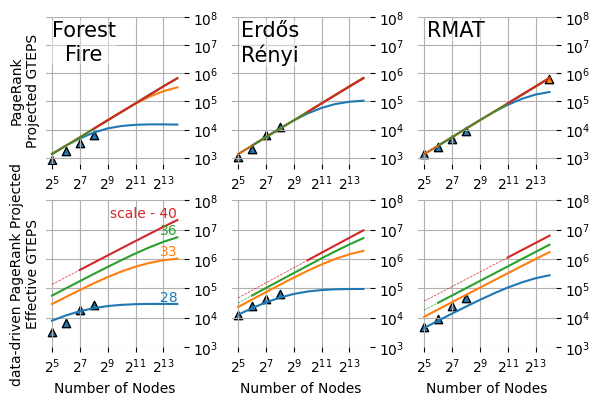

In [30]:
pr_work_rate_fit2 = make_pr_GTEP_projection_figure(savefig=True,overlay_simulated_data=True)

PUSH PR max edges/lane/s: 37788455.16351456
bad x0: -2157.832437368686
bad x0: -276.78842543270474
bad x0: -3.056920448102167


/tmp/ipython-input-3517745897.py:9: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


PR: graph_type:FF -- scale:28
numnodes_list: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]
projections:[np.float64(41.75703809899199), np.float64(83.50680765244377), np.float64(166.92644586982402), np.float64(338.25036301046583), np.float64(692.2597319689489), np.float64(1390.2227028128548), np.float64(2688.3461669479643), np.float64(4849.809716544122), np.float64(7835.03355073566), np.float64(10992.34485230337), np.float64(13432.993570230197), np.float64(14795.992229105028), np.float64(15296.517520756239), np.float64(15291.698530903266), np.float64(15040.328450387731)]
[np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66987), np.float64(26494777368.66

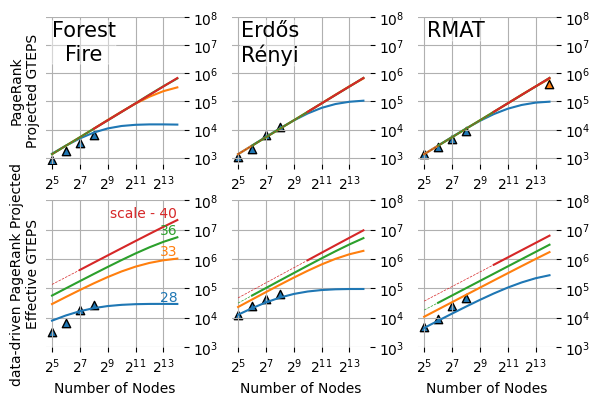

In [35]:
pr_work_rate_fit2 = make_pr_GTEP_projection_figure(savefig=True,overlay_simulated_data=True)

#BFS

In [ ]:
#
#  BFS Model
#

def bfs_er_dataset_projection(scale):
    d_avg = 35
    frontier_count = math.ceil(math.log(2**scale * d_avg, d_avg))
    # frontier i size will be d_avg^i
    ProblemSetup = namedtuple('ProblemSetup',['vertices_touched','edges_touched','vertices','edges','average_degree','num_frontiers'])
    return ProblemSetup(vertices_touched = 2**scale, #2**RMAT_scale,
                        edges_touched = 2*2**scale * d_avg,
                        vertices = 2**scale,
                        edges=2**scale * d_avg,
                        average_degree=d_avg,
                        num_frontiers = frontier_count)

def bfs_forest_fire_dataset_projection(scale):

    # edge data collected over 10 trials
    graph_scales = np.log2([256, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288, 1048576, 2097152, 4194304, 8388608, 16777216])
    edges = [1172,2324,4502,9157, 18070, 36201, 72489, 145102, 290164, 578913, 1157238, 2316556, 4632162, 9263641, 18517991, 37048602, 74081380]

    median_frontier_counts = [10.0,10.5,12.5,13.0,15.0,16.0,18.0,18.75,20.0,21.0,23.0,23.0,25.25,26.0,28.0,29.0,30.0]


    edge_r = linregress(graph_scales,np.log10(edges))
    frontier_r = linregress(graph_scales,median_frontier_counts)

    ProblemSetup = namedtuple('ProblemSetup',['vertices_touched','edges_touched','vertices','edges','num_frontiers'])
    return ProblemSetup(vertices_touched = 2**scale, #2**RMAT_scale,
                        edges_touched = 10**((edge_r.slope*scale + edge_r.intercept)), # Forest Fire Graphs are connected
                        vertices = 2**scale,
                        edges=10**((edge_r.slope*scale + edge_r.intercept)),
                        num_frontiers = frontier_r.slope*scale + frontier_r.intercept)


def bfs_preferential_attachment_dataset_projection(scale):
    ProblemSetup = namedtuple('ProblemSetup',['vertices_touched','edges_touched','vertices','edges','num_frontiers'])
    return ProblemSetup(vertices_touched = 2**scale, #2**RMAT_scale,
                        edges_touched = expected_edges_visited,
                        vertices = 2**scale,
                        edges=16*2**scale)


def bfs_rmat_dataset_projection(scale):

    ProblemSetup = namedtuple('ProblemSetup',['vertices_touched','edges_touched','vertices','edges','num_frontiers'])
    exp_data_scales = [10,12,14,16,18,20,22]
    ratio_of_edges_touched = [1.09880126953125,
                            1.242509521484375,
                            1.2426015625,
                            1.2352741165161132,
                            1.1760031700134277,
                            1.0855578474998475,
                            1.1700884662866593]
                            # > 1 bc the graph is undirected.

    exp_data_scales = [10,12,14,16,18,20]#,22,24,26,28]
    ratio_of_edges_touched = np.array([
        1.2854736328125,
        1.478036499023437,
        1.62550048828125,
        1.73480167388916,
        1.814803934097290,
        1.8716458439826966,])

    #expected_vertices_visited = 0.33 * 2**RMAT_scale# this is what happens after scale 22...
    expected_vertices_visited = 2**scale - Graph500_isolated_nodes(scale)
                                # vast majority of non-isolated nodes will be in the
                                # largest connected component.


    r = linregress(exp_data_scales,np.log10(2 - ratio_of_edges_touched))
    expected_edges_visited = (2 - 10**((r.slope*scale+ r.intercept)))*(16*2**scale)
    #expected_edges_visited = 2*16*2**RMAT_scale # we touch each edge twice.

    return ProblemSetup(vertices_touched = expected_vertices_visited, #2**RMAT_scale,
                        edges_touched =2*16*2**scale, # expected_edges_visited,
                        vertices = 2**scale,
                        edges=16*2**scale,
                        num_frontiers = 8)# RMAT graphs frontier's don't grow quickly

In [ ]:

#
#  Performance Data
#

# Best fit for work saturation figures.
def hockey_stick(x, A, x0, k):
    return A * x / (1 + (x / x0)**k)

# -- BFS Data

def auto_load_balancing_BFS_perf():

    lane_counts = [2048, 	4096, 	8192, 	16384, 	32768, 	65536, 	131072, 	262144, 	524288, 	1048576]

    bfs_runtimes = {
        "livejournal":pd.read_csv(StringIO('''active_set_size,outgoing size,2048,4096,8192,16384,32768,65536,131072,262144,524288,1048576
        1,436,22700,51100,63300,63600,75800,77700,77700,77700,77700,77700
        436,72436,27500,83200,83000,84800,84900,85000,101400,101600,103800,106100
        49735,4531896,356900,234000,198400,153300,123600,108700,107200,106200,96500,98200
        1100212,45010186,2635600,1857500,1294900,741700,394300,231600,168600,130800,118600,118500
        2584350,31514897,1764800,1419300,974700,542600,298300,185800,149400,127300,117000,117000
        962497,4133114,294700,258400,192000,137900,126200,116300,115800,106200,105600,105900
        127863,374238,50400,103400,104900,104600,103500,104600,104900,94400,95100,94400
        16409,47953,24200,82400,92100,92600,94100,92200,93800,83300,81800,82300
        2058,4728,23200,69300,79800,81200,81100,81000,80800,69700,70800,69000
        350,1395,22500,68800,68500,68500,68500,68900,68600,58500,58500,58500
        39,86,21500,45900,46000,46100,48400,48400,48100,48100,48100,48500
        3,3,20400,40400,40400,40400,40400,40400,40400,40400,40400,40400
        '''), header=0),
        "orkut":pd.read_csv(StringIO('''active_set_size,outgoing size,2048,4096,8192,16384,32768,65536,131072,262144,524288,1048576
        1,12,21300,41300,41300,41300,41300,41300,41300,41300,41300,41300
        12,589,23000,48900,61200,61200,63400,63400,63400,63300,63400,63400
        469,40548,25500,82800,84800,84900,84500,84600,84500,86400,88800,89000
        26888,3547545,263800,187000,157700,137100,111800,107900,106900,96400,98100,100400
        800020,83961870,4585600,2972100,2093000,1138300,596300,333400,215300,155500,131100,119300
        2226334,146612759,4753900,2857900,2059600,1214900,624000,355800,239500,167000,136700,125700
        18712,206837,21800,75900,87900,88100,78100,78100,78100,78400,78400,78500
        5,6,20400,40400,40400,40400,40400,40400,40400,40400,40400,40400
        '''), header=0),
        "protein":pd.read_csv(StringIO('''active_set_size,outgoing size,2048,4096,8192,16384,32768,65536,131072,262144,524288,1048576
        1,474,22700,49200,51400,65700,75800,77700,77700,77700,77700,77700
        474,349322,36400,82200,82700,84500,84200,84500,84300,74400,74600,76700
        7940,3984904,97100,133100,113400,103700,103400,92400,92800,93900,93700,83500
        836,66391,24800,81700,82500,82600,84700,83800,84100,84400,84700,89000
        2670,841649,69000,96600,94600,94300,83400,95100,95200,84800,84900,85000
        34780,20371641,628100,478000,336400,233400,163500,128500,116800,106200,95900,95500
        75661,34392158,874300,798600,520600,294500,210400,146700,124600,104400,105500,95600
        4946,571768,43300,94400,94100,95400,95100,94800,95000,95100,95100,96900
        18014,9374234,313100,259300,198100,151600,128500,106100,106000,95500,95200,95100
        18850,4365814,166900,167100,143200,117200,105500,105700,95500,95500,95400,95100
        27036,11384954,377500,309000,241400,170600,127300,106200,105300,94900,95100,95400
        13563,2296162,84800,117200,105300,105100,95700,94700,94800,95000,95000,94900
        15232,3604658,124200,139600,115600,106000,103800,95300,95000,94500,94700,94300
        6942,587643,44200,93800,94000,93500,93300,94100,93200,94300,94400,84700
        5724,480486,39000,93700,94500,95000,94600,94500,94500,94800,84500,84700
        9167,1020528,62200,96200,95200,95000,95000,94800,95100,95000,94700,84600
        20435,3289691,135500,144300,117100,116100,105300,105500,95200,95200,94900,94900
        26569,2632822,118000,130700,118300,105700,105300,95500,95000,95000,95200,95200
        25764,2014485,93200,113000,105400,105300,95300,95100,95500,95200,95100,94800
        21509,1656870,77200,106100,105100,105200,105000,94900,95400,95200,94900,94600
        15637,1250824,68000,107300,104400,94100,94500,94900,95000,94900,94900,94800
        15733,1532704,78300,107200,105300,104900,95000,95200,95000,94800,94700,95100
        16226,1381573,62400,103900,104600,95000,94800,95000,94900,95000,94900,94700
        12002,808392,52400,93800,94400,94100,93000,94300,94400,94200,84300,94200
        5635,246857,27300,92800,93200,92900,94800,94100,94700,94500,84500,84200
        3428,161104,26400,92900,92700,94000,94500,84000,84300,84600,84300,84600
        4135,858025,51300,82500,93100,93000,94700,94000,94500,84800,84500,94400
        2672,330125,27100,82800,93000,92500,92500,94100,84100,84400,84200,84200
        1831,171387,25800,82800,84100,92500,92600,83900,84400,84100,83900,84100
        2105,159779,26100,82600,92800,94400,94300,83900,84200,84400,84500,84300
        4615,574572,44800,94300,93400,94100,93700,94300,92200,93800,84100,84100
        1665,257109,25600,82400,82600,82300,84300,83600,84300,83800,84200,84200
        1248,151504,25100,82000,82300,81200,81900,81900,84100,81900,83900,81900
        775,41980,24000,80100,82400,81900,82100,81800,83600,83800,83900,84000
        1150,71751,23700,79800,81500,82100,81500,81700,81500,83600,83600,83700
        347,9182,23200,71600,79200,81300,81200,71000,71000,71100,71300,71500
        168,3372,23100,68900,69200,71000,71000,71100,72200,63400,73300,72300
        124,2399,22800,69100,68700,71000,71100,70900,61000,61000,60900,61100
        65,1126,22400,58900,58600,60800,60700,58700,60800,60700,60700,60600
        38,414,21900,46100,46100,48100,48200,48500,48500,48500,48500,48500
        8,39,21200,41300,45700,47900,47900,47900,47900,47900,47900,47900
        1,2,20400,40400,40400,40400,40400,40400,40400,40400,40400,40400
        '''), header=0),
        "twitter":pd.read_csv(StringIO('''active_set_size,outgoing size,2048,4096,8192,16384,32768,65536,131072,262144,524288,1048576
        1,1001159,140900,110000,100900,84800,82200,93200,94600,106800,109000,111200
        1001159,241660635,14425300,9210800,6938300,4205200,2351500,1248600,728000,515000,826500,538200
        19875048,2000798388,116166200,79355100,52680900,30315700,15856400,7903700,3880600,1952600,1061900,665400
        20220738,160662736,9590200,6808500,4423800,2440300,1190500,602700,338000,226100,162400,148100
        533446,874736,96200,131700,115300,115100,103300,103200,102800,102800,104400,104600
        20562,26828,24100,90000,90000,90900,91300,91000,89500,80900,81100,81300
        1127,1387,23100,68900,79100,79300,69100,68900,68700,68800,68800,68700
        104,140,22300,57900,68500,68800,58400,58500,58400,58500,58400,58400
        22,39,21900,58200,46000,48200,48200,48200,48300,48200,48200,48300
        11,23,21500,46000,46000,48200,48200,48200,48200,48200,48200,48200
        5,7,21300,41300,47900,47900,47900,47900,47900,47900,47900,47900
        2,4,21300,47900,47900,47900,47900,47900,47900,47900,47900,47900
        2,4,21300,47900,47900,45700,47900,47900,47900,47900,47900,47900
        2,4,21200,45700,47900,47900,47900,47900,47900,47900,47900,47900
        1,2,20400,40400,40400,40400,40400,40400,40400,40400,40400,40400
        '''), header=0),
        "rmat28":pd.read_csv(StringIO('''active_set_size,outgoing size,2048,4096,8192,16384,32768,65536,131072,262144,524288,1048576
        1,51,21900,50400,50500,50500,50500,50600,50600,50500,50500,50500
        51,1743028,227000,153400,118800,156200,116600,96500,94600,106800,107000,109100
        1284793,2243775882,117727500,78616800,56519800,33913700,18054900,9437000,4963100,2562500,1335100,705800
        71634207,1919772215,116137400,73879500,54914200,31482400,17169600,9087400,4491400,2207500,1067200,672400
        11136583,13700004,1114400,796900,559200,362700,239300,174900,134800,125300,112600,112300
        31332,31413,22700,89000,88700,89100,78800,78600,78700,78700,78600,78800
        65,67,21300,45700,58000,47900,48100,48100,48100,48100,48100,48100
        2,2,20400,40400,40400,40400,40400,40400,40400,40400,40400,40400
        '''), header=0),
        "ForestFire28":pd.read_csv(StringIO('''active_set_size,outgoing size,2048,4096,8192,16384,32768,65536,131072,262144,524288,1048576
        1,1,21100,45500,45500,45500,45500,45500,45500,45500,45500,45500
        1,2,21100,45500,45500,45500,45500,45500,45500,45500,45500,45500
        1,4,21100,45500,45500,45500,45500,45500,45500,45500,45500,45500
        3,11,21200,43200,47900,47900,47900,47900,45700,47900,47900,47900
        1,14,21300,45600,45700,45700,45700,45700,45700,45700,45700,45700
        12,88,22000,46200,48200,48500,48400,48500,48300,48300,48300,48300
        35,345,23000,61000,61100,51100,61200,63200,63300,63300,63200,63300
        156,1447,23600,69500,71800,71900,71400,73700,75900,75900,75900,75700
        505,5975,24000,71800,84200,82100,84000,83700,83900,74000,75600,75900
        2022,21232,24600,82400,84400,82300,84000,84000,84000,83900,84000,84000
        6128,47679,25300,92900,94500,94700,92700,94700,94500,84400,84200,84300
        12944,83058,26600,93200,95100,94200,94800,94600,94700,84800,84500,84200
        20865,117838,27700,93200,105200,105000,94700,94800,94900,94800,94700,94700
        29174,173584,39100,93200,105600,104800,95300,95000,94800,94900,94800,94800
        45305,285862,43200,104400,105900,105300,105200,105700,104900,95300,94900,94900
        74920,483573,60600,107200,106100,105900,105300,105600,105300,95300,95200,95400
        132521,973924,107300,124300,121500,118000,106200,106600,105500,105600,105600,105300
        284110,2384335,218000,201100,155800,135800,120000,117200,106400,105900,105900,105700
        717082,6521678,558100,428400,323500,212400,153200,135600,119500,106600,106600,106100
        2035142,19212790,1565200,1041500,835700,506600,298400,197000,149300,121900,118000,116700
        5852945,49987117,3961000,2413500,1896800,1195500,676100,380300,237700,164700,133900,118600
        14019755,100490688,7847000,4548100,3551600,2261900,1274100,714500,404300,226400,163300,133400
        26034533,155344885,12215300,7210200,5435400,3272300,1862500,1053300,585100,329500,205000,159000
        37752961,191254038,15060300,9197700,6884200,4154900,2296000,1301500,722600,406200,235400,171500
        44182047,194166678,15709200,9650200,7250000,4317200,2400400,1361900,770400,416900,247100,171800
        42934718,166655182,13958400,8682900,6461500,3896400,2153400,1213300,692800,373400,229200,157900
        35436721,123733552,10486700,6747300,4968000,3057100,1707300,975900,538600,309400,187800,153400
        25401916,80913475,7100000,4630000,3434200,2074500,1197300,680300,380000,216200,156900,129300
        16068531,47237867,4309000,2839900,2102700,1291400,769800,433700,262200,159900,129800,127800
        9073851,24862079,2249500,1580600,1199300,773500,444900,273000,170000,129500,127600,116800
        4639781,11964253,1122500,839400,632700,404400,248400,158700,128800,117500,116800,116100
        2163609,5280457,528700,462200,329700,229400,144500,127800,116500,116000,116000,115800
        927447,2164001,245600,216600,178700,131000,116000,116100,115500,105500,105600,105300
        371852,837772,103100,121700,116700,114700,103900,103600,104800,105200,105200,102800
        140107,304682,52700,104500,113700,103300,103100,103000,102900,92800,92900,92400
        49659,104556,26600,91000,103200,102800,92600,92500,94200,92200,92300,91900
        16709,33786,24300,90200,91900,91700,91900,91900,92000,81700,81700,81500
        5264,10323,23700,79900,91400,91800,81400,81500,81500,81400,81300,81200
        1544,2909,23400,69500,79500,79500,81000,81300,80900,70800,70900,68800
        428,768,22800,69000,80800,68900,68900,68800,68900,58800,58700,58700
        110,182,22100,58500,68600,70500,68400,58500,58500,58500,58500,58500
        29,51,21900,48400,48200,48200,48200,48200,48200,48300,48300,48200
        11,13,20400,40400,40600,40600,40600,40600,40600,40600,40600,40600
        '''), header=0),
        "ER_scale28_davg35":pd.read_csv(StringIO('''active_set_size,outgoing size,2048,4096,8192,16384,32768,65536,131072,262144,524288,1048576
        1,33,21600,48000,48100,48100,48100,48200,48200,48200,48200,48200
        33,1235,23100,61100,61300,61200,63400,75700,75500,75600,75700,75600
        1202,43556,26100,82700,84700,94500,96500,96700,98400,98500,98600,90400
        42349,1523019,203600,167000,140000,117900,112700,109200,108100,109600,109600,111400
        1476333,53138449,6520700,3627500,2347900,1406900,770400,438600,283200,195200,155800,136300
        46731853,1677737659,98908200,60311100,44876600,28841000,14199400,7386300,3985300,2056400,1117600,626000
        219685131,7648457796,373483400,246688400,167241700,97892500,40235800,15678400,7183800,3528200,1813300,1071400
        498554,14314145,260400,290400,230400,150600,110600,100600,93100,93100,83100,95600
        '''), header=0),
        }

    x_data = []
    y_data = []


    runtime_start_column = 2
    for (key, pd_data) in bfs_runtimes.items():
        #lane_counts = [int(lane) for lane in pd_data.iloc[0, runtime_start_column:]]
        runtime_in_seconds = np.array(list(map(lambda tick: tick/2e9, pd_data.iloc[1:,2:].to_numpy())))
        work = [float(vertices) + float(edges) for (vertices,edges) in zip(pd_data['active_set_size'].loc[1:],pd_data['outgoing size'].loc[1:])]

        for idx in range(runtime_start_column,len(lane_counts)):
            lanes = lane_counts[idx]
            work_per_lane = [w/lanes for w in work]
            work_per_lane_per_second = np.divide(work_per_lane,runtime_in_seconds[:,idx])

            x_data.extend(work_per_lane)
            y_data.extend(work_per_lane_per_second)

    popt, _ = curve_fit(hockey_stick, x_data, y_data, p0=[1e7, 10, 2])

    print(f"load balancing max edges/lane/s: {max(y_data)}")

    if UPDATE_BFS_TOO:
        return x_data, y_data, lambda edge_per_lane: hockey_stick(1e5,*popt) if edge_per_lane > 1e5 else hockey_stick(edge_per_lane, *popt)
    else:
        return x_data, y_data, lambda edge_per_lane: min(hockey_stick(edge_per_lane, *popt),max(y_data))


def BFS_perf():
    nodes = [1,2,4,8,16,32,64,128,256,512]
    lanes_per_node = 64*32
    lane_counts = [lanes_per_node*node_count for node_count in nodes]

    data = {
    "wiki_topcats":(pd.read_csv(StringIO('''
    28900,37700,37800,38100,39000,40300,48000,48100,48500,49400
    30600,40000,42300,43100,45200,46200,54600,54900,55300,56000
    79500,70500,72100,71400,71800,66900,74200,74300,74700,75700
    753900,443500,305200,206000,169500,131300,136800,130600,129300,118600
    970900,523900,326600,241900,175200,151600,151700,124300,121700,120800
    233100,106700,32600,33900,35000,37100,45400,46000,46500,47500
    18200,27600,24300,24700,25500,26800,35700,35700,36100,37000
    8800,24100,24100,24500,25200,26400,35200,35500,35800,36700
    8700,21600,23900,24400,25000,26600,35200,35100,35600,36100
    '''), header=None),pd.read_csv(StringIO('''
    1,1,1,1,1,1,1,1,1,1
    4,4,4,4,4,4,4,4,4,4
    4536,4536,4537,4537,4537,4537,4536,4536,4536,4536
    266296,265215,265172,265178,265171,265179,265187,265182,265180,265173
    2368651,1493265,1475374,1475367,1475362,1475366,1475368,1475362,1475372,1475363
    1692704,81989,48424,48424,48424,48424,48424,48424,48424,48424
    21840,757,316,316,316,316,316,316,316,316
    17,12,12,12,12,12,12,12,12,12
    2,2,2,2,2,2,2,2,2,2
    '''), header=None),pd.read_csv(StringIO('''
    4,4,4,4,4,4,4,4,4,4
    5649,5649,5649,5649,5649,5649,5649,5649,5649,5649
    432448,432448,432448,432448,432448,432448,432448,432448,432448,432448
    20848057,20848057,20848057,20848057,20848057,20848057,20848057,20848057,20848057,20848057
    29376112,29376112,29376112,29376112,29376112,29376112,29376112,29376112,29376112,29376112
    229306,229306,229306,229306,229306,229306,229306,229306,229306,229306
    482,482,482,482,482,482,482,482,482,482
    19,19,19,19,19,19,19,19,19,19
    3,3,3,3,3,3,3,3,3,3
    '''), header=None)),
    "forest_fire_scale28":(pd.read_csv(StringIO('''
    28900,36500,37800,38100,39000,40300,48000,48100,48500,49400
    8100,19300,24100,24200,24800,25900,32600,35200,35500,36000
    8500,21700,21500,24100,24600,26400,32900,32600,35200,35700
    8600,24100,23900,24600,25000,26600,35600,35500,35900,36400
    8600,22000,21800,22300,23000,24100,35500,35200,35800,36600
    8800,24100,24100,24600,25400,26700,35600,35400,35900,36700
    9200,24100,24200,25000,25500,27100,35600,35600,36200,36800
    9900,24600,25200,25500,26300,27200,35900,36300,36400,37600
    10300,24600,25100,25400,26200,27700,36300,36600,36800,37600
    11300,24900,25200,25600,26400,27700,36700,36600,36900,37700
    11900,25000,25200,25400,26700,28200,36400,36800,37200,38200
    14400,24900,25300,26100,26700,28200,36900,37200,37500,38200
    15800,26100,26300,26100,27000,28600,37200,37300,37900,38600
    19200,26500,26900,27000,27700,28900,37200,37100,37800,38600
    25500,27600,26800,26900,27300,29400,37600,37600,38000,38600
    32300,32100,29600,29700,30400,30900,39500,39300,39800,40700
    53600,42300,35200,33700,33000,32700,40600,40800,41400,42600
    103300,69200,52300,42800,40200,39900,46200,46300,46500,47000
    242500,144800,90200,62000,49800,45600,50700,49700,49800,50600
    679800,356200,198400,122300,78200,55100,53300,49000,44900,45600
    1929600,931600,489200,281900,160800,95100,71800,55300,47600,45300
    4476700,2138400,1064700,576600,312800,171200,107700,72100,56500,48000
    7894600,3808800,1912200,956100,505400,273400,154100,94000,64500,52000
    10942300,5423900,2742100,1317900,679800,351300,192300,113000,73200,55400
    12478900,6151100,3119900,1469600,755200,382200,204300,118400,76100,55300
    11849800,5892100,2991800,1393800,707600,367200,190600,111100,71900,53300
    9557200,4845700,2410400,1144500,575900,293800,157100,94300,63100,49800
    6815400,3370300,1709600,824200,406100,212700,116700,74600,53600,45200
    4259100,2154300,1095900,512300,257900,139300,84500,58100,46000,41500
    2403600,1217400,623300,286400,152000,83100,61400,46400,40100,38900
    1233600,633100,323100,151400,83500,53400,45700,40300,38200,37900
    578000,282000,156200,76800,50000,36900,39600,37400,37000,37400
    238800,122000,73600,46600,34100,30900,37000,36400,36700,37200
    89800,56600,39200,30600,27700,27800,36200,36200,36400,37200
    35900,32100,27500,26500,26300,27200,35900,36000,36400,37100
    17900,26300,25900,25300,25800,27100,35800,36000,36300,37100
    11600,24800,24800,25000,25700,27100,35800,35900,36200,37000
    9400,24400,24400,24800,25600,26900,35800,35800,36200,37000
    9000,24300,24400,24800,25600,27000,35700,35800,36200,37000
    8900,24200,24400,24700,25500,27000,35700,35900,36100,36900
    8900,24100,24300,24700,25500,26900,35700,35600,36100,36900
    8800,24100,24200,24800,25400,26800,35500,35500,36100,36700
    8700,23900,23900,24600,25300,26600,35300,35400,35900,36500
    '''), header=None),pd.read_csv(StringIO('''
    1,1,1,1,1,1,1,1,1,1
    1,1,1,1,1,1,1,1,1,1
    2,2,2,2,2,2,2,2,2,2
    3,3,3,3,3,3,3,3,3,3
    1,1,1,1,1,1,1,1,1,1
    12,12,12,12,12,12,12,12,12,12
    35,35,35,35,35,35,35,35,35,35
    156,156,156,156,156,156,156,156,156,156
    505,505,505,505,505,505,505,505,505,505
    2026,2022,2022,2022,2022,2022,2022,2022,2022,2022
    6141,6130,6128,6128,6128,6128,6128,6128,6128,6128
    13000,12968,12967,12944,12945,12944,12944,12944,12944,12944
    21106,20975,20974,20882,20889,20866,20865,20865,20865,20865
    29668,29401,29403,29275,29219,29188,29177,29174,29174,29174
    46757,45868,45871,45621,45424,45377,45311,45305,45305,45305
    77962,76298,76310,75685,75211,75079,74935,74930,74920,74920
    140509,136253,136361,134291,133177,132800,132594,132576,132521,132521
    311876,297896,297441,290179,286720,285011,284327,284175,284110,284110
    849650,784385,783314,748366,730736,721419,718206,717449,717082,717082
    2750340,2434762,2454086,2232673,2117537,2061401,2043538,2037255,2035142,2035142
    10214532,8518334,8646177,7375303,6502699,6053332,5922919,5870622,5852945,5852945
    32736696,27523250,27574131,22469354,18377780,15482686,14500306,14149202,14019755,14019755
    73266319,66243707,66154780,54612298,43203738,33018125,28176060,26672457,26034533,26034533
    117802838,110443716,109361092,96382171,79730026,57910959,43560956,39693786,37752961,37752961
    149548156,140339013,138028677,123184439,109249693,82248130,54595751,47851112,44182047,44182047
    154858040,145269907,142848714,126324008,114995772,91844122,56392834,47595126,42934718,42934718
    133238429,125751107,123482909,108760956,99199965,81617689,48340740,39712119,35436721,35436721
    98172787,92765453,91140187,82088879,72551894,59603846,34837376,28402693,25401916,25401916
    63094412,59726248,58499967,51967327,45988021,36621030,21468193,17740742,16068531,16068531
    35965395,34007279,33166815,29402517,24894175,19079008,11583610,9848025,9073851,9073851
    18453765,17230818,16683245,14401989,11479180,8535898,5646603,4950950,4639781,4639781
    8511441,7550911,7254963,5992897,4578473,3472309,2526157,2276843,2163609,2163609
    3401813,2719571,2642059,2112699,1613873,1316961,1048511,965318,927447,927447
    1114474,824626,862225,666816,547089,486748,411973,384535,371852,371852
    305514,246950,248279,206696,185029,174641,153426,144338,140107,140107
    84538,71338,71556,65023,61864,60241,53876,51043,49659,49659
    23057,21334,21348,20510,20133,19987,18045,17186,16709,16709
    6446,6320,6308,6212,6178,6141,5608,5374,5264,5264
    1832,1824,1818,1809,1801,1800,1651,1584,1544,1544
    495,495,495,494,494,494,451,437,428,428
    120,120,120,120,120,120,110,114,110,110
    30,30,30,30,30,30,29,30,29,29
    11,11,11,11,11,11,11,11,11,11
    '''), header=None),pd.read_csv(StringIO('''
    1,1,1,1,1,1,1,1,1,1
    2,2,2,2,2,2,2,2,2,2
    4,4,4,4,4,4,4,4,4,4
    11,11,11,11,11,11,11,11,11,11
    14,14,14,14,14,14,14,14,14,14
    88,88,88,88,88,88,88,88,88,88
    345,345,345,345,345,345,345,345,345,345
    1447,1447,1447,1447,1447,1447,1447,1447,1447,1447
    5975,5975,5975,5975,5975,5975,5975,5975,5975,5975
    21232,21232,21232,21232,21232,21232,21232,21232,21232,21232
    47679,47679,47679,47679,47679,47679,47679,47679,47679,47679
    83058,83058,83058,83058,83058,83058,83058,83058,83058,83058
    117844,117838,117838,117838,117838,117838,117838,117838,117838,117838
    173584,173584,173584,173584,173584,173584,173584,173584,173584,173584
    285866,285872,285862,285862,285862,285862,285862,285862,285862,285862
    483607,483573,483573,483586,483573,483573,483573,483573,483573,483573
    974405,974142,974043,973924,973924,973924,973924,973924,973924,973924
    2385760,2384935,2385443,2384719,2384349,2384335,2384335,2384335,2384335,2384335
    6523853,6524411,6532656,6524395,6522320,6521741,6521678,6521678,6521678,6521678
    19217309,19216388,19252259,19244487,19220423,19213266,19212890,19212802,19212790,19212790
    49995606,49997065,50111219,50087875,50055021,49997312,49987339,49987384,49987117,49987117
    100503656,100509754,100607003,100832715,100649558,100555015,100491168,100491012,100490688,100490688
    155360700,155374784,155445066,156176184,155773754,155512624,155345382,155345300,155344885,155344885
    191269484,191288670,191381853,192582480,192148641,191593444,191254230,191254317,191254038,191254038
    194181897,194200377,194305413,195769460,195434337,194748896,194166837,194167004,194166678,194166678
    166667201,166685233,166781585,168190168,167991857,167399205,166655356,166655371,166655182,166655182
    123743618,123758558,123841827,124956052,124865678,124420796,123733634,123733699,123733552,123733552
    80922093,80933070,81000854,81751383,81705956,81383785,80913583,80913579,80913475,80913475
    47244302,47253861,47301787,47771987,47690910,47520654,47237965,47237903,47237867,47237867
    24866633,24873630,24908886,25151642,25071977,24991788,24862136,24862104,24862079,24862079
    11967488,11972208,11995573,12092528,12052096,12016936,11964317,11964286,11964253,11964253
    5282658,5285967,5300562,5320907,5311618,5291613,5280460,5280457,5280457,5280457
    2165642,2167656,2175174,2173506,2169810,2165874,2164001,2164001,2164001,2164001
    838860,839359,840830,839856,838672,838059,837772,837772,837772,837772
    305077,305011,305377,305082,304775,304716,304682,304682,304682,304682
    104641,104603,104611,104576,104579,104561,104556,104556,104556,104556
    33786,33788,33790,33786,33786,33786,33786,33786,33786,33786
    10323,10323,10323,10323,10323,10323,10323,10323,10323,10323
    2909,2909,2909,2909,2909,2909,2909,2909,2909,2909
    768,768,768,768,768,768,768,768,768,768
    182,182,182,182,182,182,182,182,182,182
    51,51,51,51,51,51,51,51,51,51
    13,13,13,13,13,13,13,13,13,13
    '''), header=None)),
    "twitter":(
        pd.read_csv(StringIO('''
    128400,126600,123000,123100,122900,123900,130300,130400,129000,129900
    7426200,3798400,2167500,1243700,761800,519300,436200,339900,330800,290200
    58405200,28546300,16174800,8443100,6261500,2525300,1674700,1094900,870000,628300
    43062200,17072200,10769500,3589000,1699400,1224600,877800,262200,153700,134500
    4781000,2722100,1641600,836900,370800,225900,182800,100500,55000,55900
    46100,44400,44100,49500,56000,29300,38600,36600,37100,37800
    13800,24400,24500,24800,25600,26900,35800,35900,36200,37000
    8800,24100,24200,24700,25400,26900,35500,35700,36100,36900
    8700,23900,24100,24500,25300,26700,35300,35400,35900,36700
    8800,24000,24200,24700,25500,26700,35200,35600,35900,36600
    8500,19400,24000,24500,25300,26400,35200,35400,35700,36400
    8500,19500,21700,24400,25200,26300,35300,35100,35700,36400
    8500,21900,23700,24300,25300,26500,35600,35300,35600,36400
    8600,21900,23800,24300,24900,26500,35200,35500,35700,36100
    8400,21800,24100,24400,25200,26500,35500,35400,35600,36300
    '''), header=None),pd.read_csv(StringIO('''
    1,1,1,1,1,1,1,1,1,1
    1001159,1001159,1001159,1001159,1001159,1001159,1001159,1001159,1001159,1001159
    108463398,70809442,70389980,39071116,31643128,25129521,27819295,20043293,20041313,20041555
    1077302431,801156316,845687158,496409474,368475717,228757397,256212944,20316841,20220738,20220738
    128420183,133683755,137303456,114655935,57539340,20857466,15690106,560394,533446,533446
    667062,543265,554312,344333,176281,91570,68127,20769,20562,20562
    15176,10576,10391,4513,1892,1201,1222,1128,1127,1127
    168,124,132,117,110,105,105,104,104,104
    23,23,23,23,23,23,22,22,22,22
    12,12,12,12,11,11,11,11,11,11
    5,5,5,5,5,5,5,5,5,5
    2,2,2,2,2,2,2,2,2,2
    2,2,2,2,2,2,2,2,2,2
    2,2,2,2,2,2,2,2,2,2
    2,2,2,2,2,2,1,1,1,1
    '''), header=None),pd.read_csv(StringIO('''
    1001159,1001159,1001159,1001159,1001159,1001159,1001159,1001159,1001159,1001159
    241660649,241660649,241660649,241660649,241660649,241660649,241660649,241660649,241660649,241660649
    2001366162,2001158144,2006731233,2004679628,2003807914,2002938047,2023047066,2000835508,2000798613,2000798613
    160665136,160668660,160692666,160991227,161390834,160662970,160662963,160662790,160662790,160662790
    874758,874791,874964,875020,875354,874740,874742,874740,874740,874740
    26842,26849,26871,26832,26838,26829,26829,26829,26829,26829
    1387,1387,1387,1387,1387,1387,1387,1387,1387,1387
    140,140,140,140,140,140,140,140,140,140
    39,39,39,39,39,39,39,39,39,39
    23,23,23,23,23,23,23,23,23,23
    7,7,7,7,7,7,7,7,7,7
    4,4,4,4,4,4,4,4,4,4
    4,4,4,4,4,4,4,4,4,4
    4,4,4,4,4,4,4,4,4,4
    2,2,2,2,2,2,2,2,2,2
    '''), header=None)),
    "soc-live_journal":(pd.read_csv(StringIO('''
    30100,41000,41100,43600,44500,45800,52400,52500,52800,53700
    25500,36300,41500,41700,44300,41700,49700,50200,50500,50700
    132500,95300,79200,66200,62100,59200,58600,58400,58600,59600
    1097300,637500,385300,229800,158200,122700,111300,96700,94400,94900
    1210200,560900,335900,217100,146300,104700,97300,93300,83500,73200
    672500,218000,137400,102400,86400,72100,67600,63100,61200,60200
    160900,55700,51600,31800,48100,31200,39200,39100,39800,40700
    33600,25800,27100,28100,29400,30100,38200,39100,39400,40100
    17200,24500,24500,25000,25900,27100,35800,35900,36200,37200
    9000,24200,24400,24700,25600,27000,35700,35800,36100,36900
    9000,24300,24200,24800,25600,26800,35800,36000,36100,36900
    8500,23900,24000,24400,25300,26500,35300,35500,35800,36800
    '''), header=None),pd.read_csv(StringIO('''
    1,1,1,1,1,1,1,1,1,1
    94,94,94,94,94,94,94,94,94,94
    20693,20692,20692,20692,20692,20693,20693,20692,20692,20692
    684796,654533,653992,653647,654329,653645,653641,653636,653645,653643
    4930596,2552800,2556646,2469290,2544507,2469287,2469288,2469289,2469291,2469290
    8142574,1664153,1786378,1426667,1749699,1426668,1426666,1426666,1426667,1426663
    2419864,327542,320612,242050,322653,242050,242050,242050,242050,242050
    142569,33942,32350,29908,34381,29908,29908,29908,29908,29908
    6712,3904,3840,3821,3883,3821,3821,3821,3821,3821
    769,570,565,565,567,565,565,565,565,565
    177,133,133,133,133,133,133,133,133,133
    10,10,10,10,10,10,10,10,10,10
    '''), header=None),pd.read_csv(StringIO('''
    94,94,94,94,94,94,94,94,94,94
    21947,21947,21947,21947,21947,21947,21947,21947,21947,21947
    2331152,2331152,2331152,2331152,2331152,2331152,2331152,2331152,2331152,2331152
    37091977,37091977,37092982,37091977,37095062,37091977,37091977,37091977,37091977,37091977
    36880174,36880174,36880174,36880174,36880339,36880174,36880174,36880174,36880174,36880174
    8938762,8938762,8938762,8938762,8938776,8938762,8938762,8938762,8938762,8938762
    841868,841868,841868,841868,841868,841868,841868,841868,841868,841868
    90130,90130,90130,90130,90130,90130,90130,90130,90130,90130
    9969,9969,9969,9969,9969,9969,9969,9969,9969,9969
    1680,1680,1680,1680,1680,1680,1680,1680,1680,1680
    666,666,666,666,666,666,666,666,666,666
    15,15,15,15,15,15,15,15,15,15
    '''), header=None)),
    "RMAT":(pd.read_csv(StringIO('''
    28900,42100,42200,42500,43400,44700,51300,51400,51700,52600
    48000,60600,61100,64700,65200,66400,74100,73900,74100,71100
    43018100,21219200,11100300,6415600,3422900,1918000,1130200,809800,519200,360100
    211231700,97723100,57297700,31600300,14641000,7852600,4118200,2205000,1432500,942900
    137887700,50989100,32091200,14818300,4090300,2553200,1140600,276200,54400,44800
    1582300,840600,453300,259500,151600,92300,48400,37800,36300,37000
    11800,25000,24500,24700,25300,26700,35600,35700,36100,36800
    8200,19100,19200,19600,20200,21600,-1,-1,-1,-1
    '''), header=None),pd.read_csv(StringIO('''
    1,1,1,1,1,1,1,1,1,1
    7,7,7,7,7,7,7,7,7,7
    119310,119304,119306,119303,119302,119302,119301,119301,119301,119301
    900023997,635899132,650744620,411363084,255207600,199203526,114447835,67290274,66783964,66765031
    3935522902,2943233040,3149138092,2223914152,1407577095,1468947377,760335741,46509261,32179633,32179633
    46560790,48225572,47093262,50176348,50855786,45716005,9430241,178099,66981,66981
    66738,65623,65681,60625,43014,25311,5046,151,64,64
    59,39,41,23,10,2,-1,-1,-1,-1
    '''), header=None),pd.read_csv(StringIO('''
    7,7,7,7,7,7,7,7,7,7
    120028,120028,120028,120028,120028,120028,120028,120028,120028,120028
    1568176265,1568083982,1569500619,1568923296,1567247518,1566949887,1567478053,1566799527,1566793521,1566793521
    6641722980,6641836696,6656197385,6675523390,6671800386,6655755050,6661241068,6642284393,6641280450,6641280450
    60379067,60379258,60380301,60382835,60388621,60386399,60379018,60379018,60379018,60379018
    67140,67140,67142,67140,67140,67140,67140,67140,67140,67140
    64,64,64,64,64,64,64,64,64,64
    0,0,0,0,0,0,-1,-1,-1,-1
    '''), header=None)),
    "ER":(pd.read_csv(StringIO('''
    29300,38100,38200,40700,43800,45100,51700,51800,52100,53000
    9300,24600,24800,25100,26000,27300,36000,36200,36400,37200
    13100,25100,25100,25800,26100,27600,36300,36400,36700,37400
    68900,49200,38400,32000,30000,29100,37500,37700,37900,38500
    1855100,906700,458100,262400,148200,91100,69300,54200,46900,43000
    56390800,25702300,12868100,11100400,3931600,1961100,996900,517900,280200,157700
    286309200,142100400,71096000,69145800,30963700,9856900,4536700,2272500,1140500,589900
    285686500,140052700,70053700,33632700,15417600,6311600,1752200,164300,38800,38900
    566600,295200,160400,89200,53400,34000,32100,31200,-1,-1
    '''), header=None),pd.read_csv(StringIO('''
    1,1,1,1,1,1,1,1,1,1
    33,33,33,33,33,33,33,33,33,33
    1203,1203,1203,1203,1203,1203,1203,1203,1203,1203
    42349,42349,42349,42349,42349,42349,42349,42349,42349,42349
    1477278,1476729,1476768,1476498,1476418,1476355,1476336,1476337,1476333,1476333
    51171817,50430118,50441167,49390453,48294205,47424519,46862772,46772431,46731853,46731853
    1649284374,1619843047,1617853794,1554106424,1422765586,1136878473,493539152,305434307,219685133,219685131
    7530141380,7410924099,7403326196,7140207898,6568255434,5192877199,1596564721,500039653,498560,498554
    14090559,13861392,13848271,13313356,12077774,9034728,2554066,862277,-1,-1
    '''), header=None),pd.read_csv(StringIO('''
    33,33,33,33,33,33,33,33,33,33
    1235,1235,1235,1235,1235,1235,1235,1235,1235,1235
    43556,43556,43556,43556,43556,43556,43556,43556,43556,43556
    1523019,1523019,1523019,1523019,1523019,1523019,1523019,1523019,1523019,1523019
    53138476,53138449,53138522,53138483,53138489,53138449,53138449,53138449,53138449,53138449
    1677749119,1677747050,1677744857,1677947916,1678146027,1677855055,1677738016,1677738127,1677737659,1677737659
    7648470772,7648487901,7648571898,7652963635,7672254323,7702795983,7648458086,7648458706,7648457796,7648457796
    14314215,14314342,14314787,14315881,14318234,14322568,14314145,14314145,14314145,14314145
    0,0,0,0,0,0,0,0,-1,-1
    '''), header=None)),
    "orkut":(pd.read_csv(StringIO('''
    29000,40000,42300,42600,43500,44800,51400,51500,51800,52700
    10200,22500,24700,25400,26600,27900,36100,36300,36900,37800
    19600,30200,32100,32900,33900,35200,42800,43100,43600,45300
    183500,118300,98000,81800,78100,66100,72300,71800,70100,70900
    2238100,1171200,682300,422300,282200,218800,183800,148000,119200,115500
    4509100,1994500,1093900,643500,400600,283200,199100,160000,149900,149000
    2031700,116400,26400,26800,121000,29500,37500,38000,38600,39500
    18600,22400,24200,24400,25400,26500,35400,35600,35700,36700
    '''), header=None),pd.read_csv(StringIO('''
    1,1,1,1,1,1,1,1,1,1
    12,12,12,12,12,12,12,12,12,12
    470,470,470,470,470,470,470,470,470,470
    26894,26894,26894,26894,26894,26894,26894,26894,26894,26894
    827242,802008,800950,800949,801585,800947,800938,800946,800943,800944
    13117230,2657532,2227455,2227490,2548350,2227469,2227475,2227482,2227474,2227476
    29562588,1448184,18712,18712,1567757,18712,18712,18712,18712,18712
    24845,2198,5,5,2741,5,5,5,5,5
    '''), header=None),pd.read_csv(StringIO('''
    12,12,12,12,12,12,12,12,12,12
    589,589,589,589,589,589,589,589,589,589
    40548,40548,40548,40548,40548,40548,40548,40548,40548,40548
    3547545,3547545,3547545,3547545,3547545,3547545,3547545,3547545,3547545,3547545
    83964819,83961870,83961870,83961870,83962167,83961870,83961870,83961870,83961870,83961870
    146612759,146612759,146612759,146612759,146615198,146612759,146612759,146612759,146612759,146612759
    206837,206837,206837,206837,206837,206837,206837,206837,206837,206837
    6,6,6,6,6,6,6,6,6,6
    '''), header=None)),
    "protein":(pd.read_csv(StringIO('''
    37500,44800,46500,46800,47700,49000,55600,55700,56000,56900
    26900,36500,38300,40200,40800,42200,48800,48600,49400,50100
    425300,269800,167300,132200,105800,80700,81100,66200,63800,61600
    14167200,6740900,4403100,2274700,1243400,681400,399600,273100,176900,142100
    19212800,6913500,4148800,2211700,1220900,657000,375400,238900,164800,126000
    9660800,1357700,879100,316300,208400,122200,133600,88600,76800,70300
    974500,160700,121900,72800,60000,59800,68300,65500,65700,58500
    81800,47100,48200,47700,41500,42800,49200,49700,50500,50200
    27700,33500,38100,37700,38300,39600,46400,48500,48800,49600
    18700,29900,29800,31900,32800,34000,42600,42800,43000,43900
    9100,22400,25000,25400,25700,26800,35700,36100,34600,34900
    8100,19000,19100,-1,-1,-1,30300,-1,-1,-1
    '''), header=None),pd.read_csv(StringIO('''
    1,1,1,1,1,1,1,1,1,1
    523,523,523,523,523,523,523,523,523,523
    77496,77488,77488,77486,77486,77486,77486,77486,77486,77486
    5169280,3942913,3987532,3791760,3814951,3772310,3823499,3772220,3772203,3772186
    151316978,22417119,27829860,5858674,8130456,3732455,6830086,3731813,3731329,3730472
    254904226,34272048,45641126,4725448,9971542,371586,9422724,371365,371722,372058
    25510305,3316793,3737364,277703,531675,24038,395214,24034,24039,24030
    1282635,173648,224815,22484,44490,1437,43249,1437,1437,1438
    68570,7630,9420,903,1728,87,1478,87,87,87
    3362,411,513,57,88,10,108,10,10,10
    291,29,37,6,11,2,11,2,2,2
    45,7,9,-1,-1,-1,2,-1,-1,-1
    '''), header=None),pd.read_csv(StringIO('''
    523,523,523,523,523,523,523,523,523,523
    79529,79529,79529,79529,79529,79529,79529,79529,79529,79529
    11675206,11675206,11675206,11675206,11675206,11675206,11675206,11675206,11675206,11675206
    561789130,561785609,561865153,561796824,561831372,561785493,561808955,561785493,561785493,561785493
    550679538,550682394,551470877,550693188,550758252,550675432,550743773,550675432,550675432,550675432
    55229399,55229399,55229657,55229960,55229399,55229399,55229625,55229399,55229399,55229399
    3590505,3590505,3590527,3590505,3590505,3590505,3590505,3590505,3590505,3590505
    209559,209559,209559,209559,209559,209559,209559,209559,209559,209559
    10396,10396,10396,10396,10396,10396,10396,10396,10396,10396
    1225,1225,1225,1225,1225,1225,1225,1225,1225,1225
    79,79,79,79,79,79,79,79,79,79
    0,0,0,-1,-1,-1,0,-1,-1,
    '''), header=None))
    }

    parsed_data = {}
    for (key,(ticks,vertices, edges)) in data.items():
        runtime_in_seconds = np.array(list(map(lambda tick: tick/2e9, ticks.to_numpy())))
        work = vertices.to_numpy() + edges.to_numpy()
        parsed_data[key] = (runtime_in_seconds,work)

    x_data = []
    y_data = []

    for (key, (runtime_in_seconds, work)) in parsed_data.items():

        for idx in range(len(lane_counts)):
            lanes = lane_counts[idx]

            for frontier in range(work.shape[0]):
                if work[frontier,idx] == 0 or work[frontier,idx] == -1 or runtime_in_seconds[frontier,idx] == 0 or runtime_in_seconds[frontier,idx] == -5e-10:
                    continue
                work_per_lane = work[frontier,idx]/lane_counts[idx]
                work_per_lane_per_second = work_per_lane/runtime_in_seconds[frontier,idx]

                x_data.append(work_per_lane)
                y_data.append(work_per_lane_per_second)


    print(f"Jiya max edges/lane/s: {max(y_data)}")



    popt, _ = curve_fit(hockey_stick, x_data, y_data, p0=[1e7, 10, 2])
    if UPDATE_BFS_TOO:
        return x_data, y_data, lambda edge_per_lane: hockey_stick(1e5,*popt) if edge_per_lane > 1e5 else hockey_stick(edge_per_lane, *popt)
    else:
        return x_data, y_data, lambda edge_per_lane: min(hockey_stick(edge_per_lane, *popt),max(y_data))

In [ ]:
#
#   BFS Projection Model
#


def high_degree_subsampling(edges, nodes):
    SubSampledEdgesProb = .01
    IngestEdgesPerSecondPerLane = 150264.0186 # from GEM5 12/30
    return max(
        edges*SubSampledEdgesProb/IngestEdgesPerSecondPerLane/(nodes*LanesPerNode),
        2*edges*16*SubSampledEdgesProb / (DRAMBandwidth*nodes))


def time_build_adj(problem, nodes):
    maxdeg = 3 * 256  # degrees are split to 256
                    # (add in a factor of 3 for fudgefactor)

    avgworkperlane = problem.edges/(nodes*LanesPerNode)

    BuildAdjAggregationRatePerLane = 2e8 # measured for PDR
    taillatency = maxdeg/BuildAdjAggregationRatePerLane  + maxdeg*RoundtripTime/16

    avgtime = avgworkperlane/BuildAdjAggregationRatePerLane + avgworkperlane*RoundtripTime/16
    return 2*(taillatency + avgtime) # factor of 2 accounts for two passes needed o
                                        # over the edges


def bfs_runtime(data_model,work_rate_fit,num_lanes):

    nodes = num_lanes/2048
    work_per_lane = (data_model.vertices+data_model.edges_touched)/num_lanes
    work_rate = work_rate_fit(work_per_lane)
    network_injection_time = (8*(data_model.vertices+data_model.edges_touched)/nodes)/NetworkInjectionPerNodeBandwidth
                            #8 bytes per vertex/edge

    #print(f"work_t:{work_per_lane/work_rate} -- {network_injection_time}")
    graph_traversal_time = max(work_per_lane/work_rate,network_injection_time)
    return graph_traversal_time + 2*data_model.num_frontiers*RoundtripTime*math.ceil(math.log2(nodes))
                                  #barrier modeling

In [ ]:
# -- BFS Figures

def make_bfs_GTEP_projection_figure(savefig=False, overlay_simulated_data=False):
    """
        Condensed plot which makes the different algorithms different rows in the figure
    """
    def projection(data_model,method,numnodes):
        lanes = 2048*numnodes
        return bfs_runtime(data_model,method,lanes)

    def simple_formatter(x, pos):
        return f'{int(x)}'

    def feasible(data_model,numnodes):
        #data_model = rmat_dataset_projection(scale)

        memrequired = (data_model.edges*8 + # 16 edges per node, 8 bytes per edge
                        data_model.vertices*16) # 16 bytes per node for distance/parent

        #need space to store the frontiers
        max_frontier_size_mem = data_model.edges_touched * 8
                                    # frontier size projections run very large.
                                    # frontier cannot be larger than the number of
                                    # edges in the graph.
        memrequired += max_frontier_size_mem

        return memrequired < numnodes*512e9 # 512 GB/node

    numnodes_list = [32, 64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]


    #plt.ioff()
    fig = plt.figure(figsize=(6,4))
    bbox = dict(boxstyle="round", ec="w", fc="w", alpha=.4,pad=.00)
    graph_labels = ["Forest\nFire","Erdős\nRényi","RMAT"]
    graph_types = ["FF", "ER", "RMAT"]
    methods = ["Push BFS","load balancing BFS"]

    # Need to show this as GTEPS
    rows = len(methods)
    cols = len(graph_labels)
    gs = fig.add_gridspec(rows, cols,
                        left=0.1, right=0.9,top=.975,bottom=0.125,
                        wspace=0.25,hspace=.25)

    all_axes = np.empty((rows,cols),dtype=object)


    for i in range(rows):
        for j in range(cols):
            if i == 0:
                all_axes[i,j] = fig.add_subplot(gs[i,j])
            else:
                all_axes[i,j] = fig.add_subplot(gs[i,j],sharey=all_axes[i,0])

    # graph_types = ["FF","RMAT", "ER"]
    scales = [28,33,36,40]
    simulated_nodes = [32, 64, 128, 256]
    #method = "Push-BFS"


    for (i,method) in enumerate(methods):

        if method == "load balancing BFS":
            _,_,work_rate_fit = auto_load_balancing_BFS_perf()
        elif method == "Push BFS":
            _,_,work_rate_fit = BFS_perf()
        else:
            raise ValueError(f"`method` passes in must be one of 'auto_load_balanced_BFS' or `Cached BFS`. Got:{method}")

        for (k,scale) in enumerate(scales):
            for (j,graph_type) in enumerate(graph_types):
                if graph_type == "RMAT":
                    data_model = bfs_rmat_dataset_projection(scale)
                    if method == "load balancing BFS":
                        simulated_gteps= [869.7679596076473, 1670.150893280952, 3168.1928617954713, 5824.029970065153]
                    else:
                        simulated_gteps=[5475.031650389009, 10047.592867124371, 13908.60647603028, 18230.99228309999]
                elif graph_type == "ER":
                    data_model = bfs_er_dataset_projection(scale)
                    if method == "load balancing BFS":
                        simulated_gteps = [785.1035061022742, 1582.2722038465424, 3028.3702591542033, 5365.781942374139]
                    else:
                        simulated_gteps=[1525.222145164694, 2804.3327787478547, 4883.422159155881, 8069.758120678549]
                elif graph_type == "FF":
                    data_model = bfs_forest_fire_dataset_projection(scale)
                    if method == "load balancing BFS":
                        simulated_gteps = [210.03396839737118, 314.07868902398644, 441.88385323494333, 533.3255763218856]
                    else:
                        simulated_gteps=[204.69636500181275, 280.17267775703584, 435.48914824065236, 654.7367358771882]
                else:
                    raise ValueError(f"inputted `graph_type` must be one of: 'RMAT', 'ER', or 'FF'. got {graph_type}\n")

                projections = [data_model.edges_touched/projection(data_model,work_rate_fit,numnodes) /1e9 for numnodes in numnodes_list]
                line1, = all_axes[i,j].loglog(numnodes_list, projections, linestyle="--", linewidth=0.5)
                feasible_nodes = [numnodes for numnodes in numnodes_list if feasible(data_model, numnodes)]
                projections = [data_model.edges_touched/projection(data_model,work_rate_fit,numnodes)/1e9 for numnodes in feasible_nodes]

                print(f"graph_type:{graph_type} -- scale:{scale}\n projections:{projections}")

                if k == len(scales)-1:
                    label = f'scale - {scale}'
                else:
                    label = f"{scale}"
                all_axes[i,j].loglog(feasible_nodes, projections, label=label, color=line1.get_color())

                if overlay_simulated_data and scale == 28:
                    all_axes[i,j].scatter(simulated_nodes,simulated_gteps,marker="^",color=line1.get_color(),edgecolor='black')

                if overlay_simulated_data and scale == 33 and graph_type == "RMAT" and method == "Push BFS":
                    all_axes[i,j].scatter([14000],[BFS_GTEPS],marker="^",color=line1.get_color(), edgecolor='black')

                if i == 0 and j == 0:
                    idx = len(feasible_nodes) // 2
                    all_axes[i,j].annotate(label,(feasible_nodes[-1],projections[-1]),xycoords="data",ha="right",va="bottom",color=line1.get_color(),zorder=5)


    for i in range(rows):
        for j in range(cols):
            ax = all_axes[i,j]

            ax.set_xscale('log', base=2)
            ax.set_yscale('log', base=10)
            #plt.gca().xaxis.set_major_locator(LogLocator(base=2))

            ax.yaxis.tick_right()

            if i ==0:
                ax.annotate(graph_labels[j],xy=(.1,.8),fontsize=15,xycoords="axes fraction",ha="left",va="center").set_bbox(bbox)
            #if box is not None:
            if i == 1:
                ax.set_xlabel('Number of Nodes')
            if j == 0:
                ax.set_ylabel(f'{methods[i]}\nProjected GTEPs',fontsize=12)

            #if i == 0 and j == 1:
                #ax.set_title(f'Projected {method} Compute Rate for Different Scales, Graphs, and Nodes',fontsize=11)
                #ax.legend(loc='lower right')

            if j == 2:
                pass

            ax.set_xticks(numnodes_list[::2])
            if i == 0:
                ax.set_yticks([1e2,1e3,1e4,1e5,1e6,1e7])
                ax.set_ylim((95,2e7))
            else:
                ax.set_yticks([1e2,1e3,1e4,1e5,1e6])
                ax.set_ylim((95,2e6))

            ax.grid(True, which="both", ls="-")
            ax.grid(which='minor', axis='both', linestyle='', color='none')
            ax.spines[:].set_visible(False)

            ax.set_xlim((2**5-5,2**14+5))

    if savefig:
        plt.savefig(RENDER_LOC+"BFS_projected_GTEPSv2.pdf")
    else:
        plt.show()



def print_bfs_GTEPs(graph_type,method,scale):
    nodes = [32,	64,	128,	256,	512,	1024,	2048,	4096,	8192,	16384]

    nodes = [256, 16384]

    if method == "load_balancing_BFS":
        _,_,work_rate_fit = auto_load_balancing_BFS_perf()
    elif method == "Cached BFS":
        _,_,work_rate_fit = BFS_perf()
    else:
        raise ValueError(f"`method` passes in must be one of 'load_balancing_BFS' or `Cached BFS`. Got:{method}")

    if graph_type == "RMAT":
        data_model = bfs_rmat_dataset_projection(scale)
    elif graph_type == "ER":
        data_model = bfs_er_dataset_projection(scale)
    elif graph_type == "FF":
        data_model = bfs_forest_fire_dataset_projection(scale)
    else:
        raise ValueError(f"inputted `graph_type` must be one of: 'RMAT', 'ER', or 'FF'. got {graph_type}\n")

    print(f"edges: {data_model.edges_touched}")

    print("nodes")
    print(nodes)
    print("runtime:")
    print([bfs_runtime(data_model,work_rate_fit,numnodes*2048) for numnodes in nodes])
    print("GTEPS:")
    print([round(data_model.edges_touched/bfs_runtime(data_model,work_rate_fit,numnodes*2048)/1e9,3) for numnodes in nodes])

    return data_model


In [ ]:
print_bfs_GTEPs("RMAT", "Cached BFS", 33)

Jiya max edges/lane/s: 40978894.492250666
edges: 274877906944
nodes
[256, 16384]
runtime:
[np.float64(0.01828158566225435), np.float64(0.0009081688390092236)]
GTEPS:
[np.float64(15035.78), np.float64(302672.692)]


/tmp/ipython-input-4232775592.py:7: RuntimeWarning: invalid value encountered in power
  return A * x / (1 + (x / x0)**k)


ProblemSetup(vertices_touched=np.float64(3174899170.58963), edges_touched=274877906944, vertices=8589934592, edges=137438953472, num_frontiers=8)

In [ ]:
print_bfs_GTEPs("FF", "Cached BFS", 28)
print_bfs_GTEPs("FF", "Cached BFS", 40)
print_bfs_GTEPs("FF", "load_balancing_BFS", 28)
print_bfs_GTEPs("FF", "load_balancing_BFS", 40)

In [ ]:
print_bfs_GTEPs("ER", "Cached BFS", 28)
print_bfs_GTEPs("ER", "Cached BFS", 40)
print_bfs_GTEPs("ER", "load_balancing_BFS", 28)
print_bfs_GTEPs("ER", "load_balancing_BFS", 40)

In [ ]:
print_bfs_GTEPs("RMAT", "Cached BFS", 28)
print_bfs_GTEPs("RMAT", "Cached BFS", 33)
print_bfs_GTEPs("RMAT", "Cached BFS", 40)
print_bfs_GTEPs("RMAT", "load_balancing_BFS", 28)
print_bfs_GTEPs("RMAT", "load_balancing_BFS", 40)

In [ ]:
#
#  Figures
#

# -- Work Rate Figures
def make_work_rate_figures(savefig=False):
    fig = plt.figure(figsize=(6,3))
        # Need to show this as GTEPS
    rows = 1
    cols = 2
    gs = fig.add_gridspec(rows, cols,
                        left=0.05, right=0.9,top=.9,bottom=0.15,
                        wspace=0.25,hspace=.35)

    all_axes = np.empty((cols),dtype=object)

    for j in range(cols):
        all_axes[j] = fig.add_subplot(gs[0,j])

    projections = {
        "Cached BFS":(*BFS_perf(),"tab:blue",1,"Push BFS",(.4,.925)),
        "Brian BFS":(*auto_load_balancing_BFS_perf(),"tab:red",1,"Load Balancing\nBFS",(.45,.4)),
        "Push-PR":(*PushPageRank_perf(),"tab:green",0,"Push PR",(.6,.6)),
        "Data-Driven-PR":(*DataDrivenPageRank_perf(),"tab:purple",0,"Data Driven\nPageRank",(.025,.65))
    }


    bbox = dict(boxstyle="round", ec="w", fc="w", alpha=.75,pad=.00)
    for (key, (x_data,y_data,fit,color,ax_idx,label,xy)) in projections.items():
        all_axes[ax_idx].scatter(x_data,y_data,c=color,s=1,alpha=.25)

        if ax_idx == 0:
            fit_domain = np.logspace(-4, 8, 100)
        else:
            fit_domain = np.logspace(-2, 8, 100)
        all_axes[ax_idx].plot(fit_domain,[fit(x) for x in fit_domain],c=color)
        all_axes[ax_idx].annotate(label,xy=xy,xycoords="axes fraction",ha="left",c=color).set_bbox(bbox)


    for ax in all_axes:
        ax.set_yscale("log")
        ax.set_xscale("log")
        ax.spines[:].set_visible(False)
        ax.yaxis.tick_right()

        ax.grid(True)

    bbox = dict(boxstyle="round", ec="w", fc="w", alpha=.75,pad=.00)
    all_axes[0].set_ylabel(f"work / s / {LANE_NAME}")
    bfs_ax = 1
    pr_ax = 0
    all_axes[bfs_ax].annotate("BFS",xy=(.05,.95),fontsize=15,xycoords="axes fraction",ha="left",va="top").set_bbox(bbox)
    all_axes[bfs_ax].set_xlabel(f"work / {LANE_NAME}")

    all_axes[bfs_ax].set_yticks([10**i for i in range(-2,9)])
    all_axes[bfs_ax].set_ylim(1e-1,4e8)
    all_axes[pr_ax].annotate("PageRank",xy=(.05,.95),fontsize=15,xycoords="axes fraction",ha="left",va="top").set_bbox(bbox)
    all_axes[pr_ax].set_xlabel(f"work / {LANE_NAME}")
    all_axes[pr_ax].set_yticks([10**i for i in range(1,9)])
    all_axes[pr_ax].set_ylim(1e1,4e8)
    #all_axes[1].set_ylabel("work / s / core")

    if savefig:
        plt.savefig(RENDER_LOC+"work_rates.pdf")
    else:
        plt.show()

In [ ]:
UPDATE_BFS_TOO = False
bfs_model = print_bfs_GTEPs("RMAT", "Cached BFS", 33)

In [ ]:
time = 0.8388/1e3
BFS_GTEPS = (bfs_model.edges_touched)/time/1e9
print(f"BFS time: {round(time,6)}, GTEPS: {round(BFS_GTEPS,3)}")

In [ ]:
make_bfs_GTEP_projection_figure(savefig=True, overlay_simulated_data=True)

In [ ]:
print_bfs_GTEPs("RMAT", "Cached BFS", 33)

In [ ]:
print_bfs_GTEPs("RMAT", "Cached BFS", 40)

In [ ]:
print_bfs_GTEPs("RMAT", "Cached BFS", 41)

In [ ]:
print_bfs_GTEPs("RMAT", "Cached BFS", 42)

In [ ]:
def make_work_rate_figures(savefig=False):
    fig = plt.figure(figsize=(6,3))
        # Need to show this as GTEPS
    rows = 1
    cols = 2
    gs = fig.add_gridspec(rows, cols,
                        left=0.05, right=0.9,top=.9,bottom=0.15,
                        wspace=0.25,hspace=.35)

    all_axes = np.empty((cols),dtype=object)

    for j in range(cols):
        all_axes[j] = fig.add_subplot(gs[0,j])

    projections = {
        "Cached BFS":(*BFS_perf(),"tab:blue",1,"Push BFS",(.4,.925)),
        "Brian BFS":(*auto_load_balancing_BFS_perf(),"tab:red",1,"Load Balancing\nBFS",(.45,.4)),
        "Push-PR":(*PushPageRank_perf(),"tab:green",0,"Push PR",(.1,.65)),
        "Data-Driven-PR":(*DataDrivenPageRank_perf(),"tab:purple",0,"Data Driven\nPageRank",(.6,.6))
    }


    bbox = dict(boxstyle="round", ec="w", fc="w", alpha=.75,pad=.00)
    for (key, (x_data,y_data,fit,color,ax_idx,label,xy)) in projections.items():
        all_axes[ax_idx].scatter(x_data,y_data,c=color,s=1,alpha=.25)

        if ax_idx == 0:
            fit_domain = np.logspace(-4, 8, 100)
        else:
            fit_domain = np.logspace(-2, 8, 100)
        all_axes[ax_idx].plot(fit_domain,[fit(x) for x in fit_domain],c=color)
        all_axes[ax_idx].annotate(label,xy=xy,xycoords="axes fraction",ha="left",c=color).set_bbox(bbox)


    for ax in all_axes:
        ax.set_yscale("log")
        ax.set_xscale("log")
        ax.spines[:].set_visible(False)
        ax.yaxis.tick_right()

        ax.grid(True)

    bbox = dict(boxstyle="round", ec="w", fc="w", alpha=.75,pad=.00)
    all_axes[0].set_ylabel("work / s / core")
    bfs_ax = 1
    pr_ax = 0
    all_axes[bfs_ax].annotate("BFS",xy=(.05,.95),fontsize=15,xycoords="axes fraction",ha="left",va="top").set_bbox(bbox)
    all_axes[bfs_ax].set_xlabel("work / core")

    all_axes[bfs_ax].set_yticks([10**i for i in range(-2,9)])
    all_axes[bfs_ax].set_ylim(1e-1,4e8)
    all_axes[pr_ax].annotate("PageRank",xy=(.05,.95),fontsize=15,xycoords="axes fraction",ha="left",va="top").set_bbox(bbox)
    all_axes[pr_ax].set_xlabel("work / core")
    all_axes[pr_ax].set_yticks([10**i for i in range(1,9)])
    all_axes[pr_ax].set_ylim(1e1,4e8)
    #all_axes[1].set_ylabel("work / s / core")

    if savefig:
        plt.savefig(RENDER_LOC+"work_rates.pdf")
    else:
        plt.show()


In [ ]:
make_work_rate_figures(True)

In [ ]:
def DataDrivenPageRank_perf(show = True):

    nodes = [1,2,4,8,16,32,64,128,256]
    lanes_per_node = 64*32
    lane_counts = [lanes_per_node*node_count for node_count in nodes]

    nodes = [1,2,4,8,16,32,64,128,256]
    lanes_per_node = 64*32
    lane_counts = [lanes_per_node*node_count for node_count in nodes]
    data_driven_pr_1_over_n_tol_raw_data = {
    "wiki-topcats":(pd.read_csv(io.StringIO('''
    2218002,1946202,1132602,605902,405402,282302,245702,215202,213302
    2149100,1779800,1083500,562400,357200,243300,219300,186100,178300
    1983300,1391800,867900,463200,296800,203200,178300,156300,144800
    1911900,1167500,623400,410100,249100,183100,174800,144900,142900
    1893202,1030400,580200,327400,213100,163700,149500,131700,130500
    '''), header=None),pd.read_csv(io.StringIO('''
    47971451,47971451,47971451,47971451,47971451,47971451,47971451,47971451,47971451
    43140294,43140294,43140294,43140294,43140294,43140294,43140294,43140294,43140294
    25345700,25345700,25345700,25345700,25345700,25345700,25345700,25345700,25345700
    11981592,11981592,11981592,11981592,11981592,11981592,11981592,11981592,11981592
    3110710,3110710,3110710,3110710,3110710,3110710,3110710,3110710,3110710
    '''), header=None),pd.read_csv(io.StringIO('''
    1487672,1487672,1487672,1487672,1487672,1487672,1487672,1487672,1487672
    1186125,1186125,1186125,1186125,1186125,1186125,1186125,1186125,1186125
    409538,409538,409538,409538,409538,409538,409538,409538,409538
    95586,95586,95586,95586,95586,95586,95586,95586,95586
    14739,14739,14739,14739,14739,14739,14739,14739,14739
    '''), header=None)),
    "soc-livejournal":(pd.read_csv(io.StringIO('''
    4240002,2894402,1614002,892702,522502,340902,254602,209802,1039702
    4141700,2267400,1280300,754800,438200,271400,213000,173700,153300
    3926700,2182500,1246700,708200,418700,271500,211000,161500,151800
    3543300,1893300,1157300,665700,411000,261000,198400,167500,142700
    2871902,1517800,994300,598200,366200,252200,188100,149700,133600
    '''), header=None),pd.read_csv(io.StringIO('''
    47251164,47251164,47251164,47251164,47251164,47251164,47251164,47251164,47251164
    32657388,32657388,32657388,32657388,32657388,32657388,32657388,32657388,32657388
    20754197,20754197,20754197,20754197,20754197,20754197,20754197,20754197,20754197
    12543778,12543778,12543778,12543778,12543778,12543778,12543778,12543778,12543778
    6450608,6450608,6450608,6450608,6450608,6450608,6450608,6450608,6450608
    '''), header=None),pd.read_csv(io.StringIO('''
    858443,858443,858443,858443,858443,858443,858443,858443,858443
    427826,427826,427826,427826,427826,427826,427826,427826,427826
    187233,187233,187233,187233,187233,187233,187233,187233,187233
    81369,81369,81369,81369,81369,81369,81369,81369,81369
    31188,31188,31188,31188,31188,31188,31188,31188,31188
    '''), header=None)),
    "orkut":(pd.read_csv(io.StringIO('''
    3421702,2959602,1594602,946602,548402,353802,245102,203002,191602
    3148800,2126600,1200200,693300,420200,278400,203400,163400,147400
    2706500,1456600,847000,519600,309000,237700,184600,158600,139700
    1231002,781200,564900,433700,301600,207000,162400,139100,129900
    517600,407400,240500,287500,250600,182900,160500,132200,124800
    '''), header=None),pd.read_csv(io.StringIO('''
    80469498,80469498,80469498,80469498,80469498,80469498,80469498,80469498,80469498
    46441311,46441311,46441311,46441311,46441311,46441311,46441311,46441311,46441311
    9614490,9614490,9614490,9614490,9614490,9614490,9614490,9614490,9614490
    1410956,1410956,1410956,1410956,1410956,1410956,1410956,1410956,1410956
    184608,184608,184608,184608,184608,184608,184608,184608,184608
    '''), header=None),pd.read_csv(io.StringIO('''
    433947,433947,433947,433947,433947,433947,433947,433947,433947
    204042,204042,204042,204042,204042,204042,204042,204042,204042
    15666,15666,15666,15666,15666,15666,15666,15666,15666
    2332,2332,2332,2332,2332,2332,2332,2332,2332
    832,832,832,832,832,832,832,832,832
    '''), header=None)),
    "twitter":(pd.read_csv(io.StringIO('''
    62881002,66731102,35199502,20292202,10960702,5898102,3388402,1897302,1250002
    60662600,65213300,34262900,19745000,10583500,5841500,3398500,1844400,1171300
    59862100,63337000,33494300,19447200,10411900,5716300,3401800,1850800,1165500
    58360100,61570600,32934100,18800100,10215300,5574600,3210800,1794300,1175800
    57770800,60296300,33961200,18426900,10126800,5545000,3155500,1811700,1167400
    '''), header=None),pd.read_csv(io.StringIO('''
    2308550422,2308550422,2308550422,2308550422,2308550422,2308550422,2308550422,2308550422,2308550422
    2274944397,2274944397,2274944397,2274944397,2274944397,2274944397,2274944397,2274944397,2274944397
    2227703661,2227703661,2227703661,2227703661,2227703661,2227703661,2227703661,2227703661,2227703661
    2185091727,2185091727,2185091727,2185091727,2185091727,2185091727,2185091727,2185091727,2185091727
    2137883693,2137883693,2137883693,2137883693,2137883693,2137883693,2137883693,2137883693,2137883693
    '''), header=None),pd.read_csv(io.StringIO('''
    26602830,26602830,26602830,26602830,26602830,26602830,26602830,26602830,26602830
    26515372,26515372,26515372,26515372,26515372,26515372,26515372,26515372,26515372
    24026345,24026345,24026345,24026345,24026345,24026345,24026345,24026345,24026345
    23659597,23659597,23659597,23659597,23659597,23659597,23659597,23659597,23659597
    22165561,22165561,22165561,22165561,22165561,22165561,22165561,22165561,22165561
    '''), header=None)),
    "Forest Fire":(pd.read_csv(io.StringIO('''
    33501404,15667102,10768302,5836602,3377402,1078204,1078204,660102,456002
    27636500,14203400,9382000,5195200,2880000,830298,830298,472000,302600
    26371400,13305300,9057200,5083500,2806500,796200,796200,438800,295400
    26265000,13225200,9117000,5063200,2815700,784602,784602,432200,262300
    26276300,13224500,9113300,5093600,2811300,778700,778700,438100,259600
    '''), header=None),pd.read_csv(io.StringIO('''
    6880973,6880973,6880973,6880973,6880973,6880973,6880973,6880973,6880973
    960823,960823,960823,960823,960823,960823,960823,960823,960823
    131933,131933,131933,131933,131933,131933,131933,131933,131933
    20518,20518,20518,20518,20518,20518,20518,20518,20518
    7597,7597,7597,7597,7597,7597,7597,7597,7597
    '''), header=None),pd.read_csv(io.StringIO('''
    255300,255300,255300,255300,255300,255300,255300,255300,255300
    31147,31147,31147,31147,31147,31147,31147,31147,31147
    4067,4067,4067,4067,4067,4067,4067,4067,4067
    683,683,683,683,683,683,683,683,683
    204,204,204,204,204,204,204,204,204
    '''), header=None)),
    "RMAT":(pd.read_csv(io.StringIO('''
    -1,177935002,139718502,76561602,40079902,21046202,10733902,5904402,3598302
    -1,175738200,139275800,76471600,39527400,20784500,10724700,5849100,3521200
    -1,177367700,139712400,78140700,39605000,20896200,10674200,5937400,3586300
    -1,171749300,135043200,72761500,38680900,20280900,10483000,5840900,3537200
    -1,164172100,127266300,70760600,37420200,19722000,10241400,5783300,3513000
    '''), header=None),pd.read_csv(io.StringIO('''
    -1,8257725129,8257725129,8257725129,8257725129,8257725129,8257725129,8257725129,8257725129
    -1,8257336744,8257336744,8257336744,8257336744,8257336744,8257336744,8257336744,8257336744
    -1,8254785133,8254785133,8254785133,8254785133,8254785133,8254785133,8254785133,8254785133
    -1,8257421189,8257421189,8257421189,8257421189,8257421189,8257421189,8257421189,8257421189
    -1,8244812543,8244812543,8244812543,8244812543,8244812543,8244812543,8244812543,8244812543
    '''), header=None),pd.read_csv(io.StringIO('''
    -1,88426329,88426329,88426329,88426329,88426329,88426329,88426329,88426329
    -1,88224431,88224431,88224431,88224431,88224431,88224431,88224431,88224431
    -1,86418839,86418839,86418839,86418839,86418839,86418839,86418839,86418839
    -1,88289365,88289365,88289365,88289365,88289365,88289365,88289365,88289365
    -1,80452677,80452677,80452677,80452677,80452677,80452677,80452677,80452677
    '''), header=None)),
    "ER":(pd.read_csv(io.StringIO('''
    26233304,13215802,8997602,5006102,2804002,1524402,805704,454002,289402
    -1,-1,-1,-1,-1,-1,-1,-1,-1
    -1,-1,-1,-1,-1,-1,-1,-1,-1
    -1,-1,-1,-1,-1,-1,-1,-1,-1
    -1,-1,-1,-1,-1,-1,-1,-1,-1
    '''), header=None),pd.read_csv(io.StringIO('''
    9395215892,9395215892,9395215892,9395215892,9395215892,9395215892,9395215892,9395215892,9395215892
    0,0,0,0,0,0,0,0,0
    0,0,0,0,0,0,0,0,0
    0,0,0,0,0,0,0,0,0
    0,0,0,0,0,0,0,0,0
    '''), header=None),pd.read_csv(io.StringIO('''
    268435456,268435456,268435456,268435456,268435456,268435456,268435456,268435456,268435456
    0,0,0,0,0,0,0,0,0
    0,0,0,0,0,0,0,0,0
    0,0,0,0,0,0,0,0,0
    0,0,0,0,0,0,0,0,0
    '''), header=None)),
    }

    x_data = []
    y_data = []

    x_data1 = []
    y_data1 = []

    x_data2 = []
    y_data2 = []


    for (graph_key,(sim_ticks,active_set_volume, active_vertices)) in data_driven_pr_1_over_n_tol_raw_data.items():
        runtime_in_seconds = np.array(list(map(lambda tick: tick/2e9, sim_ticks.to_numpy())))
        work = active_set_volume.to_numpy() + active_vertices.to_numpy()

        for iter in range(5):
                for i in range(len(lane_counts)):
                    if work[iter,i] <= 0 or runtime_in_seconds[iter,i] <= 0:
                        continue
                    work_per_lane = work[iter,i] / lane_counts[i]
                    work_per_lane_per_second = work_per_lane/runtime_in_seconds[iter,i]

                    x_data.append(work_per_lane)
                    y_data.append(work_per_lane_per_second)

                    if graph_key != "ER":
                        x_data1.append(work_per_lane)
                        y_data1.append(work_per_lane_per_second)

                    if (graph_key != "RMAT" and work_per_lane < 1000) or graph_key == "ER":
                        x_data2.append(work_per_lane)
                        y_data2.append(work_per_lane_per_second)



    # popt, _ = curve_fit(hockey_stick, x_data, y_data, p0=[1e7, 10, 2])
    popt1, _ = curve_fit(
        hockey_stick,
        x_data1,
        y_data1,
        p0=[1e7, 10, 2],          # 接近你饱和点的猜测
        bounds=(
            [0, 1e-6, 0],          # 物理下界
            [np.inf, np.inf, 10]   # k 通常不需要太大
        ), maxfev=40000
    )

    popt2, _ = curve_fit(
        hockey_stick,
        x_data2,
        y_data2,
        p0=[1e7, 10, 2],          # 接近你饱和点的猜测
        bounds=(
            [0, 1e-6, 0],          # 物理下界
            [np.inf, np.inf, 10]   # k 通常不需要太大
        ), maxfev=20000
    )

    # print(f"popt1: {popt1}")
    # print(f"popt2: {popt2}")
    if show:
        # return x_data, y_data, [lambda edge_per_lane: hockey_stick(1e5,*popt1) if edge_per_lane > 1e6 else hockey_stick(edge_per_lane, *popt1), lambda edge_per_lane: hockey_stick(edge_per_lane, *popt2)]
        return x_data, y_data, [lambda edge_per_lane: hockey_stick(edge_per_lane, *popt1), lambda edge_per_lane: hockey_stick(edge_per_lane, *popt2)]
        # return x_data, y_data, lambda edge_per_lane: hockey_stick(edge_per_lane, *popt2)
    else:
        return lambda edge_per_lane: hockey_stick(edge_per_lane, *popt1), lambda edge_per_lane: hockey_stick(edge_per_lane, *popt2)

In [ ]:
# -- PageRnnk Data

# Best fit for work saturation figures.
def hockey_stick(x, A, x0, k):
    # if np.any(x < 0):
    #     print("negative x detected")
    # if x0 <= 0:
    #     print("bad x0:", x0)
    return A * x / (1 + (x / x0)**k)

def PushPageRank_perf(show = True):

    nodes = [1,2,4,8,16,32,64,128,256]
    lane_counts = [node*2048 for node in nodes]

    pr_1_iteration_simticks =pd.read_csv(io.StringIO('''
    1471200,807300,473400,308300,186800,129800,108100,91400,94300
    94160500,69323800,30761200,17495200,9037100,4856100,2533300,1435500,798800
    2617000,1358100,816100,502400,307800,189700,129600,99500,89100
    6056800,3105900,1802700,1085700,596900,331800,203400,135600,118000
    380634400,428707600,121348000,48271900,23554600,11938200,6628400,3618400,1864300
    444833900,221399300,192034100,99941800,50897200,17616800,9080800,2942100,1462200
    55077600,27870400,24313300,21502800,5786300,2793600,1362100,706300,360000
    '''), header=None)

    runtime_in_seconds = np.array(list(map(lambda tick: tick/2e9, pr_1_iteration_simticks.to_numpy())))
    edges = [50888414,2405026092,85702474,234370166,8268666550,9395215892,1185662754]


    graph_names = ["wiki-topcats","Twitter","soc-liveJournal","orkut","RMAT-28","Erdos Renyi","Forest Fire"]


    x_data = []
    y_data = []
    for i in range(len(edges)):
        for (j,lanes) in enumerate(lane_counts):
            if runtime_in_seconds[i,j] == -5e-10:
                continue
            work_per_lane = edges[i]/lanes
            work_per_lane_per_second = work_per_lane/runtime_in_seconds[i,j]

            x_data.append(work_per_lane)
            y_data.append(work_per_lane_per_second)

    print(f"PUSH PR max edges/lane/s: {max(y_data)}")

    popt, _ = curve_fit(hockey_stick, x_data, y_data, p0=[1e7, 10, 2])
    if show:
        return x_data, y_data, lambda edge_per_lane: hockey_stick(1e5,*popt) if edge_per_lane > 1e5 else hockey_stick(edge_per_lane, *popt)
        # return x_data, y_data, lambda edge_per_lane: hockey_stick(edge_per_lane, *popt)
    else:
        return x_data, y_data, lambda edge_per_lane: hockey_stick(edge_per_lane, *popt)

In [ ]:
def make_work_rate_figures(savefig=False):
    fig = plt.figure(figsize=(6,3))
        # Need to show this as GTEPS
    rows = 1
    cols = 2
    gs = fig.add_gridspec(rows, cols,
                        left=0.05, right=0.9,top=.9,bottom=0.15,
                        wspace=0.25,hspace=.35)

    all_axes = np.empty((cols),dtype=object)

    for j in range(cols):
        all_axes[j] = fig.add_subplot(gs[0,j])

    projections = {
        "Cached BFS":(*BFS_perf(),"tab:blue",1,"Push BFS",(.4,.925)),
        "Brian BFS":(*auto_load_balancing_BFS_perf(),"tab:red",1,"Load Balancing\nBFS",(.45,.4)),
        "Push-PR":(*PushPageRank_perf(),"tab:green",0,"Push PR", (.1,.55)),
        "Data-Driven-PR":(*DataDrivenPageRank_perf(),"tab:purple",0,"Data Driven\nPageRank", (.5,.4))
    }


    bbox = dict(boxstyle="round", ec="w", fc="w", alpha=.75,pad=.00)
    for (key, (x_data,y_data,fit,color,ax_idx,label,xy)) in projections.items():
        if key == "Data-Driven-PR":
            all_axes[ax_idx].scatter(x_data,y_data,c=color,s=1,alpha=.25)

            if ax_idx == 0:
                fit_domain = np.logspace(-4, 8, 100)
            else:
                fit_domain = np.logspace(-2, 8, 100)
            for i in range(len(fit)):
                if(i ==0):
                    all_axes[ax_idx].plot(fit_domain,[(fit[i])(x) for x in fit_domain],c=color)
                    all_axes[ax_idx].annotate(label,xy=xy,xycoords="axes fraction",ha="left",c=color).set_bbox(bbox)
                elif i == 1:
                    all_axes[ax_idx].plot(fit_domain,[(fit[i])(x) for x in fit_domain],c="#5e3c99", linestyle="--")
                    all_axes[ax_idx].annotate("DD PR\nonly ER",xy=(.4,.925),xycoords="axes fraction",ha="left",c="#5e3c99").set_bbox(bbox)

        else:
            all_axes[ax_idx].scatter(x_data,y_data,c=color,s=1,alpha=.25)

            if ax_idx == 0:
                fit_domain = np.logspace(-4, 8, 100)
            else:
                fit_domain = np.logspace(-2, 8, 100)
            all_axes[ax_idx].plot(fit_domain,[fit(x) for x in fit_domain],c=color)
            all_axes[ax_idx].annotate(label,xy=xy,xycoords="axes fraction",ha="left",c=color).set_bbox(bbox)


    for ax in all_axes:
        ax.set_yscale("log")
        ax.set_xscale("log")
        ax.spines[:].set_visible(False)
        ax.yaxis.tick_right()

        ax.grid(True)

    bbox = dict(boxstyle="round", ec="w", fc="w", alpha=.75,pad=.00)
    all_axes[0].set_ylabel("work / s / core")
    bfs_ax = 1
    pr_ax = 0
    all_axes[bfs_ax].annotate("BFS",xy=(.05,.95),fontsize=15,xycoords="axes fraction",ha="left",va="top").set_bbox(bbox)
    all_axes[bfs_ax].set_xlabel("work / core")

    all_axes[bfs_ax].set_yticks([10**i for i in range(-2,9)])
    all_axes[bfs_ax].set_ylim(1e-1,4e8)
    all_axes[pr_ax].annotate("PageRank",xy=(.05,.85),fontsize=15,xycoords="axes fraction",ha="left",va="top").set_bbox(bbox)
    all_axes[pr_ax].set_xlabel("work / core")
    all_axes[pr_ax].set_yticks([10**i for i in range(1,9)])
    all_axes[pr_ax].set_ylim(1e1,4e8)
    #all_axes[1].set_ylabel("work / s / core")

    if savefig:
        plt.savefig(RENDER_LOC+"work_ratesv2.pdf")
    else:
        plt.show()


In [ ]:
make_work_rate_figures(True)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = np.array([8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])

y = [152, 280, 477, 792, 1343, 2228, 3653, 6019, 9574, 15728, 25296, 40199, 64868, 102487, 162656, 258471, 406881]

print(len(x))
print(len(y))

x_r = linregress(x,np.log2(y))
def y_fit(x):
    return 2**(x_r.slope*x+x_r.intercept)

# 画图（强烈建议 log y）
x_fit = np.linspace(x.min(), x.max(), 200)
y_fits = [y_fit(i) for i in x_fit]

plt.figure()
plt.plot(x, y, 'o', label='data')
plt.plot(x_fit, y_fits, '-', label='exp fit')
plt.xlabel('scale')
plt.ylabel('active set volume')
plt.legend()
plt.grid(True, which='both')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = np.array([8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])

y = [8500, 19382, 74323, 162566, 273466, 1705157, 1709906, 3530285, 9521616, 15629142, 102191939, 97903498, 286476452, 1113127605, 1000136223, 4724253001, 7750088293]

print(len(x))
print(len(y))

x_r = linregress(x,np.log2(y))
def y_fit(x):
    return 2**(x_r.slope*x+x_r.intercept)

# 画图（强烈建议 log y）
x_fit = np.linspace(x.min(), x.max(), 200)
y_fits = [y_fit(i) for i in x_fit]

plt.figure()
plt.plot(x, y, 'o', label='data')
plt.plot(x_fit, y_fits, '-', label='exp fit')
plt.xlabel('scale')
plt.plot([28], [91708564301], 'o', label='s28')
plt.yscale("log")
plt.ylabel('active set volume')
plt.legend()
plt.grid(True, which='both')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = np.array([8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])

y = [2, 5, 7, 10, 12, 15, 18, 20, 22, 25, 28, 30, 33, 36, 38, 41, 43]

print(len(x))
print(len(y))

x_r = linregress(x,y)
def y_fit(x):
    return x_r.slope*x+x_r.intercept

# 画图（强烈建议 log y）
x_fit = np.linspace(x.min(), 33, 200)
y_fits = [y_fit(i) for i in x_fit]

plt.figure()
plt.plot(x, y, 'o', label='data')
plt.plot(x_fit, y_fits, '-', label='exp fit')
plt.plot([28], [55], 'o', label='s28')
# plt.yscale("log")
plt.xlabel('scale')
plt.ylabel('active set volume')
plt.legend()
plt.grid(True, which='both')
plt.show()

print(y_fit(33))

In [ ]:
graph_scales = np.array([8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])
num_verts = [237, 458, 882, 1724, 3348, 6471, 12533, 24227, 46646, 90363, 173913, 335498, 645957, 1243894, 2396196, 4610762, 8871575]
num_edges = [4208, 9570, 21058, 45534, 97124, 203796, 425808, 882516, 1818848, 3729000, 7611394, 15481476, 31404218, 63537382, 128308980, 258669482, 520764024]
max_degs = [152, 280, 477, 792, 1343, 2228, 3653, 6019, 9574, 15728, 25296, 40199, 64868, 102487, 162656, 258471, 406881]
DD_PR_active_set_volume_sums = [8500, 19382, 74323, 162566, 273466, 1705157, 1709906, 3530285, 9521616, 15629142, 102191939, 97903498, 286476452, 1113127605, 1000136223, 4724253001, 7750088293]
DD_PR_iterations = [2, 2, 4, 4, 4, 9, 4, 5, 6, 5, 17, 7, 10, 18, 9, 23, 21]
PR_iterations = [2, 5, 7, 10, 12, 15, 18, 20, 22, 25, 28, 30, 33, 36, 38, 41, 43]

In [ ]:
# Python Code burnP:0.4
    graph_scales = np.array([8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])
    num_verts = [257, 513, 1025, 2049, 4097, 8193, 16385, 32769, 65537, 131073, 262145, 524289, 1048577, 2097153, 4194305, 8388609, 16777217]
    num_edges = [1069, 2275, 4471, 8967, 17775, 35753, 71445, 143455, 287627, 575031, 1156881, 2315799, 4631629, 9265969, 18535935, 37056331, 74109505]
    max_degs = [25, 29, 37, 47, 58, 65, 72, 84, 97, 111, 129, 147, 172, 200, 230, 264, 309]
    DD_PR_active_set_volume_sums = [1069, 2275, 4471, 8967, 17775, 36952, 71445, 143455, 298489, 587821, 1200050, 2411380, 4816419, 9671773, 19432176, 38876277, 77831552]
    DD_PR_active_set_volume_sums_2 = [0, 0, 0, 0, 0, 0, 0, 0, 2327, 3201, 7362, 17413, 23950, 53224, 124404, 257530, 559320]
    DD_PR_iterations = [1, 1, 1, 1, 1, 2, 1, 1, 3, 3, 3, 5, 4, 5, 5, 6, 5]
    PR_iterations = [1, 1, 1, 1, 1, 2, 1, 1, 6, 7, 8, 9, 10, 11, 12, 13, 14]
    PR_sum_of_active_set_volumes = [num_edges[i]*PR_iterations[i] for i in range(len(num_edges))]

    graph_scales_0 = graph_scales[8:]
    num_vert_0 = num_verts[8:]
    num_edges_0 = num_edges[8:]
    max_degs_0 = max_degs[8:]
    PR_iterations_0 = PR_iterations[8:]
    PR_sum_of_active_set_volumes_0 = PR_sum_of_active_set_volumes[8:]
    DD_PR_active_set_volume_sums_0 = DD_PR_active_set_volume_sums[8:]
    DD_PR_iterations_0 = DD_PR_iterations[8:]
    DD_PR_active_set_volume_sums_2_0 = DD_PR_active_set_volume_sums_2[8:]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = np.array([8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])

y = [1, 1, 1, 1, 1, 2, 1, 1, 6, 7, 8, 9, 10, 11, 12, 13, 14]

x=x[8:]
y=y[8:]

print(len(x))
print(len(y))

x_r = linregress(x,np.log2(y))
def y_fit(x):
    return 2**(x_r.slope*x+x_r.intercept)

# 画图（强烈建议 log y）
x_fit = np.linspace(x.min(), 33, 200)
y_fits = [y_fit(i) for i in x_fit]

plt.figure()
plt.plot(x, y, 'o', label='data')
plt.plot(x_fit, y_fits, '-', label='exp fit')
plt.plot([28], [19], 'o', label='s28')
plt.xlabel('scale')
plt.ylabel('active set volume')
plt.legend()
plt.grid(True, which='both')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = np.array([8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])

y = [1, 1, 1, 1, 1, 2, 1, 1, 6, 7, 8, 9, 10, 11, 12, 13, 14]

x=x[8:]
y=y[8:]

x_r = linregress(x,y)
def y_fit(x):
    return x_r.slope*x+x_r.intercept

# 画图（强烈建议 log y）
x_fit = np.linspace(x.min(), 33, 200)
y_fits = [y_fit(i) for i in x_fit]

plt.figure()
plt.plot(x, y, 'o', label='data')
plt.plot(x_fit, y_fits, '-', label='exp fit')
plt.plot([28], [19], 'o', label='s28')
plt.xlabel('scale')
plt.ylabel('active set volume')
plt.legend()
plt.grid(True, which='both')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x = np.array([8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])

y = [1069, 2275, 4471, 8967, 17775, 36952, 71445, 143455, 298489, 587821, 1200050, 2411380, 4816419, 9671773, 19432176, 38876277, 77831552]


print(len(x))
print(len(y))

x_r = linregress(x,np.log2(y))
def y_fit(x):
    return 2**(x_r.slope*x+x_r.intercept)

# 画图（强烈建议 log y）
x_fit = np.linspace(x.min(), 24, 200)
y_fits = [y_fit(i) for i in x_fit]

plt.figure()
plt.plot(x, y, 'o', label='data')
plt.plot(x_fit, y_fits, '-', label='exp fit')
# plt.yscale("log")
# plt.plot([28], [19], 'o', label='s28')
plt.xlabel('scale')
plt.ylabel('active set volume')
plt.legend()
plt.grid(True, which='both')
plt.show()


In [ ]:
graph_scales = np.array([8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])
num_verts = [237, 458, 882, 1724, 3348, 6471, 12533, 24227, 46646, 90363, 173913, 335498, 645957, 1243894, 2396196, 4610762, 8871575]
num_edges = [4208, 9570, 21058, 45534, 97124, 203796, 425808, 882516, 1818848, 3729000, 7611394, 15481476, 31404218, 63537382, 128308980, 258669482, 520764024]

17
17


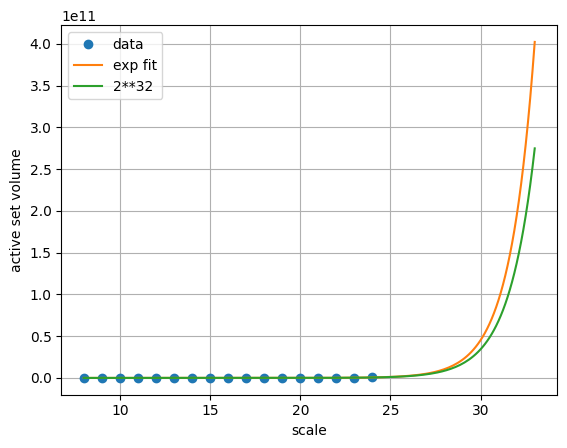

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

x=[8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
y=[4208, 9570, 21058, 45534, 97124, 203796, 425808, 882516, 1818848, 3729000, 7611394, 15481476, 31404218, 63537382, 128308980, 258669482, 520764024]

print(len(x))
print(len(y))

x=np.array(x)
y=np.array(y)

x_r = linregress(x,np.log2(y))
def y_fit(x):
    return 2**(x_r.slope*x+x_r.intercept)

# 画图（强烈建议 log y）
x_fit = np.linspace(x.min(), 33, 200)
y_fits = [y_fit(i) for i in x_fit]
y_fits2 = [(2**i) * 32 for i in x_fit]

plt.figure()
plt.plot(x, y, 'o', label='data')
plt.plot(x_fit, y_fits, '-', label='exp fit')
plt.plot(x_fit, y_fits2, '-', label='2**32')
plt.xlabel('scale')
plt.ylabel('active set volume')
plt.legend()
plt.grid(True, which='both')
plt.show()